
**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# 🏋️ PureGym Customer Reviews – NLP & Topic Modeling Project

This notebook analyzes 40,000+ customer reviews from PureGym using NLP techniques to uncover key sentiment, topics, and operational issues across locations.

> Platforms: **Google Reviews** + **Trustpilot**  
> Techniques: **BERT, BERTopic, LDA, Phi-3.5**, custom multilingual preprocessing

---

### 🔬 Analysis Pipeline

1. Data Cleaning + Multilingual Preprocessing (EN, DE, DA)
2. EDA: Term Frequencies, Location Clustering
3. Topic Modeling: BERTopic & Gensim LDA
4. Emotion Classification: FinBERT & DistilBERT
5. GenAI Insights: Phi-3.5 for deeper understanding
6. Strategic Recommendations

---

> Skip to "Topic Modeling Insights" or "Emotion-Based Themes" to see results.


# Importing packages and data

In [6]:
%pip install -q gdown transformers datasets evaluate wordcloud nltk bertopic tf-keras plotly sentence-transformers gensim pyldavis langdetect

Note: you may need to restart the kernel to use updated packages.


In [7]:
import warnings
import ipykernel

# Import required libraries
import joblib
import json
from langdetect import detect
from matplotlib.gridspec import GridSpecFromSubplotSpec
import os
import random
import sys
import gdown
import pandas as pd
import numpy as np
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
import plotly.express as px
import plotly.graph_objects as go
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
)
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from datasets import Dataset
from sklearn.metrics.pairwise import cosine_similarity
from gensim import corpora, models
import pyLDAvis
import pyLDAvis.gensim_models
from IPython.display import HTML, display
from typing import List, Any, Optional
from umap import UMAP


# If you want to disable all deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [9]:
# Set seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


In [12]:
# Define paths
folder = "CAM DS 301 Week 4&5 Topic project data sets/"
google_file = "Google_12_months.xlsx"
trustpilot_file = "Trustpilot_12_months.xlsx"

# Download files using gdown
folder_id = "1azch13dtGeAkbnEjqeoyl3nU9jheojU4"
!gdown --folder https://drive.google.com/drive/folders/{folder_id} -O data/

# Load the data
df_google = pd.read_excel(f'data/{folder}{google_file}')
df_trustpilot = pd.read_excel(f'data/{folder}{trustpilot_file}')

# Display basic information
print("\nGoogle Reviews Dataset Info:")
print(df_google.info())
print("\nTrustpilot Reviews Dataset Info:")
print(df_trustpilot.info())

Retrieving folder contents
Processing file 13TeZTT6oqk3iPELBhFx9hComIfChKw4m Google_12_months.xlsx
Processing file 1V6Pr6xWrHSHaothB61MJbR7mPFHwQ1u6 Trustpilot_12_months.xlsx
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=13TeZTT6oqk3iPELBhFx9hComIfChKw4m
To: /Users/prash/workspace/data-science-portfolio/puregym-nlp-analysis/data/CAM DS 301 Week 4&5 Topic project data sets/Google_12_months.xlsx
100%|██████████████████████████████████████| 2.08M/2.08M [00:00<00:00, 30.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V6Pr6xWrHSHaothB61MJbR7mPFHwQ1u6
To: /Users/prash/workspace/data-science-portfolio/puregym-nlp-analysis/data/CAM DS 301 Week 4&5 Topic project data sets/Trustpilot_12_months.xlsx
100%|██████████████████████████████████████| 2.83M/2.83M [00:00<00:00, 34.9MB/s]
Download completed

Google Reviews Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex:

In [ ]:
# Remove any rows with missing values in the Comment column (Google review) and Review Content column (Trustpilot).
# Before cleaning, let's see the initial number of rows
print("Before cleaning:")
print(f"Google Reviews shape: {df_google.shape}")
print(f"Trustpilot Reviews shape: {df_trustpilot.shape}")

# Remove rows with missing values in the Comment column for Google reviews
df_google_clean = df_google.dropna(subset=["Comment"])

# Remove rows with missing values in the Review Content column for Trustpilot
df_trustpilot_clean = df_trustpilot.dropna(subset=["Review Content"])

# After cleaning, let's see the number of rows removed
print("\nAfter cleaning:")
print(f"Google Reviews shape: {df_google_clean.shape}")
print(f"Trustpilot Reviews shape: {df_trustpilot_clean.shape}")

# Verify no missing values remain in these columns
print("\nMissing values check:")
print("Google Comments missing values:", df_google_clean["Comment"].isnull().sum())
print(
    "Trustpilot Review Content missing values:",
    df_trustpilot_clean["Review Content"].isnull().sum(),
)

Before cleaning:
Google Reviews shape: (23250, 7)
Trustpilot Reviews shape: (16673, 15)

After cleaning:
Google Reviews shape: (13898, 7)
Trustpilot Reviews shape: (16673, 15)

Missing values check:
Google Comments missing values: 0
Trustpilot Review Content missing values: 0


# Conducting initial data investigation

In [ ]:
# Location Analysis Functions
def analyze_locations(df_google_clean, df_trustpilot_clean):
    """Analyze unique and common locations"""
    google_locations = set(df_google_clean["Club's Name"].unique())
    trustpilot_locations = set(df_trustpilot_clean["Location Name"].unique())
    common_locations = google_locations.intersection(trustpilot_locations)

    print(f"Number of unique locations in the Google data set: {len(google_locations)}")
    print(
        f"Number of unique locations in the Trustpilot data set: {len(trustpilot_locations)}"
    )
    print(f"Number of common locations: {len(common_locations)}")

    return google_locations, trustpilot_locations, common_locations


def setup_nltk():
    """
    Initialize all necessary components for multilingual preprocessing

    Returns:
    tuple: (lemmatizer, stop_words)
    """
    # Download necessary NLTK resources if not already present
    nltk.data.path.append("/root/nltk_data")
    nltk.download('punkt')
    nltk.download('punkt_tab')
    nltk.download('averaged_perceptron_tagger_eng')
    nltk.download('averaged_perceptron_tagger')
    nltk.download('stopwords')
    nltk.download('wordnet')


def get_multilingual_stopwords():
    """
    Get combined stopwords list for multiple languages with domain-specific terms
    """
    # First ensure NLTK stopwords are downloaded
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

    # English stopwords
    english_custom = [
        # General terms
        "one", "get", "like", "dont", "use", "got", "going", "would",
        "could", "pure", "even", "go", "place", "work", "time", "times",
        "good", "ive", "always", "also", "day", "im", "never",
        # Domain-specific terms
        "puregym", "gym", "gyms", "member", "fitness", "center", "centre",
        # Common modifiers
        "really", "very", "much", "many", "lot", "way", "thing",
        "just", "make", "made", "need", "want", "every", "everything",
        # Time-related
        "today", "yesterday", "tomorrow", "week", "month", "year",
        # Generic evaluative terms
        "good", "great", "nice", "amazing", "awesome", "terrible", "horrible",
        "better", "best", "worse", "worst"
    ]

    # Danish/Norwegian stopwords
    danish_custom = [
        # Common words
        "er", "og", "det", "ikke", "på", "de", "der", "har", "jeg", "til",
        # Domain-specific terms
        "fitness", "center", "medlem", "træning", "udstyr",
        # Common modifiers
        "meget", "rigtig", "også", "bare", "lige", "altid", "aldrig",
        # Time-related
        "dag", "uge", "måned", "år", "tid",
        # Evaluative terms
        "god", "dårlig", "bedste", "værste", "dejlig", "skøn", "forfærdelig",
        # Additional common words
        "kan", "skal", "vil", "får", "havde", "været", "blevet",
        "kommer", "gør", "går", "tager", "ser", "så", "ved"
    ]

    # German stopwords
    german_custom = [
        # Common words from Topic 7
        "und", "die", "ich", "nicht", "der", "das", "ist", "es",
        # Domain-specific terms
        "fitnessstudio", "studio", "mitglied", "training", "geräte",
        # Common modifiers
        "sehr", "wirklich", "auch", "nur", "immer", "nie", "jetzt",
        # Time-related
        "tag", "woche", "monat", "jahr", "zeit",
        # Evaluative terms
        "gut", "schlecht", "beste", "schlechteste", "toll", "schrecklich",
        # Additional common words
        "kann", "muss", "soll", "wird", "wurde", "gewesen", "geworden",
        "kommt", "geht", "macht", "sieht"
    ]

    # Initialize stopwords dictionary
    all_stopwords = {
        'english': set(english_custom),
        'danish': set(danish_custom),
        'german': set(german_custom)
    }

    # Add NLTK stopwords if available
    for lang in ['english', 'danish', 'german']:
        try:
            nltk_stops = set(stopwords.words(lang))
            all_stopwords[lang].update(nltk_stops)
            print(f"Added NLTK stopwords for {lang}")
        except Exception as e:
            print(f"Note: Could not load NLTK stopwords for {lang}. Using custom stopwords only.")

    return all_stopwords


def preprocess_text(text, lemmatizer, min_length=3):
    """
    Preprocess text with improved phrase detection and context preservation
    """
    if not isinstance(text, str) or len(text.strip()) < min_length:
        return ""

    # Detect language
    try:
        lang = detect(text)
    except:
        lang = 'en'

    # Convert to lowercase
    text = text.lower()

    # Language-specific processing
    if lang == 'de':
        text = re.sub(r'[^a-zA-ZäöüßÄÖÜ\s\.\!\?]', '', text)
        stop_words = german_stops
    elif lang == 'da':
        text = re.sub(r'[^a-zA-ZæøåÆØÅ\s\.\!\?]', '', text)
        stop_words = danish_stops
    else:
        text = re.sub(r'[^a-zA-Z\s\.\!\?]', '', text)
        stop_words = english_stops

    # Split into sentences for better context
    sentences = sent_tokenize(text)
    processed_sentences = []

    for sentence in sentences:
        words = word_tokenize(sentence)

        if lang == 'en':
            tagged = pos_tag(words)

            # Extract meaningful phrases and words
            meaningful_terms = []
            i = 0
            while i < len(tagged):
                word, tag = tagged[i]

                # Skip if it's a stop word (unless part of a phrase)
                if word in english_stops and i < len(tagged)-1:
                    next_word, next_tag = tagged[i+1]
                    if not next_tag.startswith(('NN', 'JJ')):
                        i += 1
                        continue

                # Capture noun phrases (e.g., "customer service")
                if tag.startswith('JJ') and i < len(tagged)-1:
                    next_word, next_tag = tagged[i+1]
                    if next_tag.startswith('NN'):
                        phrase = f"{lemmatizer.lemmatize(word)}_{lemmatizer.lemmatize(next_word)}"
                        meaningful_terms.append(phrase)
                        i += 2
                        continue

                # Capture complaint patterns (e.g., "broken machine")
                if tag.startswith('JJ') and word in ['broken', 'poor', 'bad', 'dirty', 'expensive']:
                    if i < len(tagged)-1:
                        next_word, next_tag = tagged[i+1]
                        if next_tag.startswith('NN'):
                            phrase = f"{word}_{lemmatizer.lemmatize(next_word)}"
                            meaningful_terms.append(phrase)
                            i += 2
                            continue

                # Keep meaningful single words
                if tag.startswith(('NN', 'JJ')) and len(word) > min_length:
                    meaningful_terms.append(lemmatizer.lemmatize(word))

                i += 1

            processed_sentences.extend(meaningful_terms)

        else:
            # Simpler processing for non-English text
            filtered_words = [
                word for word in words
                if word not in stop_words
                and len(word) > min_length
                and not word.isdigit()
                and not all(c == word[0] for c in word)
            ]
            processed_sentences.extend(filtered_words)

    # Final cleaning
    processed_terms = [
        term for term in processed_sentences
        if not term.isdigit()
        and not all(c == term[0] for c in term)
        and len(term) > min_length
    ]

    return " ".join(processed_terms)


def tokenize_text(text_series):
    """
    Tokenize a series of preprocessed text, preserving phrases
    """
    def tokenize_with_phrases(text):
        if not isinstance(text, str):
            return []
        # Split on spaces but preserve underscore-connected phrases
        tokens = []
        for token in text.split():
            if '_' in token:
                # Keep phrases as single tokens
                tokens.append(token)
            else:
                # Normal word tokenization
                tokens.extend(word_tokenize(token))
        return tokens

    return text_series.apply(tokenize_with_phrases)


def get_word_frequencies(tokens_list):
    """Get word frequencies from a list of tokens"""
    all_words = [word for tokens in tokens_list for word in tokens]
    return FreqDist(all_words)


# Visualization Functions
def plot_top_words(word_freq1, word_freq2, title1, title2, n_words=10):
    """Plot top N words from two frequency distributions side by side"""
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    top_words1 = dict(word_freq1.most_common(n_words))
    plt.bar(list(top_words1.keys()), list(top_words1.values()))
    plt.title(title1)
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    top_words2 = dict(word_freq2.most_common(n_words))
    plt.bar(list(top_words2.keys()), list(top_words2.values()))
    plt.title(title2)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


def create_wordclouds(words1, title1, words2=None, title2=None):
    """Create word clouds for two sets of words side by side"""
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    wordcloud1 = WordCloud(width=800, height=400, background_color="white").generate(
        " ".join(words1)
    )
    plt.imshow(wordcloud1)
    plt.title(title1)
    plt.axis("off")

    if words2 and title2:
        plt.subplot(1, 2, 2)
        wordcloud2 = WordCloud(
            width=800, height=400, background_color="white"
        ).generate(" ".join(words2))
        plt.imshow(wordcloud2)
        plt.title(title2)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def get_negative_reviews(df_google_clean, df_trustpilot_clean):
    """Extract and analyze negative reviews"""
    negative_google = df_google_clean[df_google_clean["Overall Score"] < 3].copy()
    negative_trustpilot = df_trustpilot_clean[
        df_trustpilot_clean["Review Stars"] < 3
    ].copy()

    print("Number of negative reviews:")
    print(
        f"Google: {len(negative_google)} ({(len(negative_google)/len(df_google_clean)*100):.1f}% of total)"
    )
    print(
        f"Trustpilot: {len(negative_trustpilot)} ({(len(negative_trustpilot)/len(df_trustpilot_clean)*100):.1f}% of total)"
    )

    return negative_google, negative_trustpilot

In [ ]:
# Setup NLTK and initialize preprocessing tools
setup_nltk()

# Initialize multilingual stopwords
stopwords_dict = get_multilingual_stopwords()
danish_stops = stopwords_dict['danish']
german_stops = stopwords_dict['german']
english_stops = stopwords_dict['english']
# Combine all stopwords
all_stops = set()
for lang_stops in stopwords_dict.values():
    all_stops.update(lang_stops)

lemmatizer = WordNetLemmatizer()

Added NLTK stopwords for english
Added NLTK stopwords for danish
Added NLTK stopwords for german


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Number of unique locations in the Google data set: 512
Number of unique locations in the Trustpilot data set: 377
Number of common locations: 310

Top words in Google reviews:
{'equipment': 2767, 'class': 2661, 'machine': 1888, 'staff': 1721, 'clean': 1225, 'people': 1047, 'busy': 968, 'room': 856, 'friendly': 699, 'weight': 666}

Top words in Trustpilot reviews:
{'equipment': 3351, 'class': 2500, 'staff': 2141, 'machine': 1923, 'easy': 1732, 'clean': 1613, 'friendly': 1000, 'membership': 978, 'people': 939, 'shower': 883}


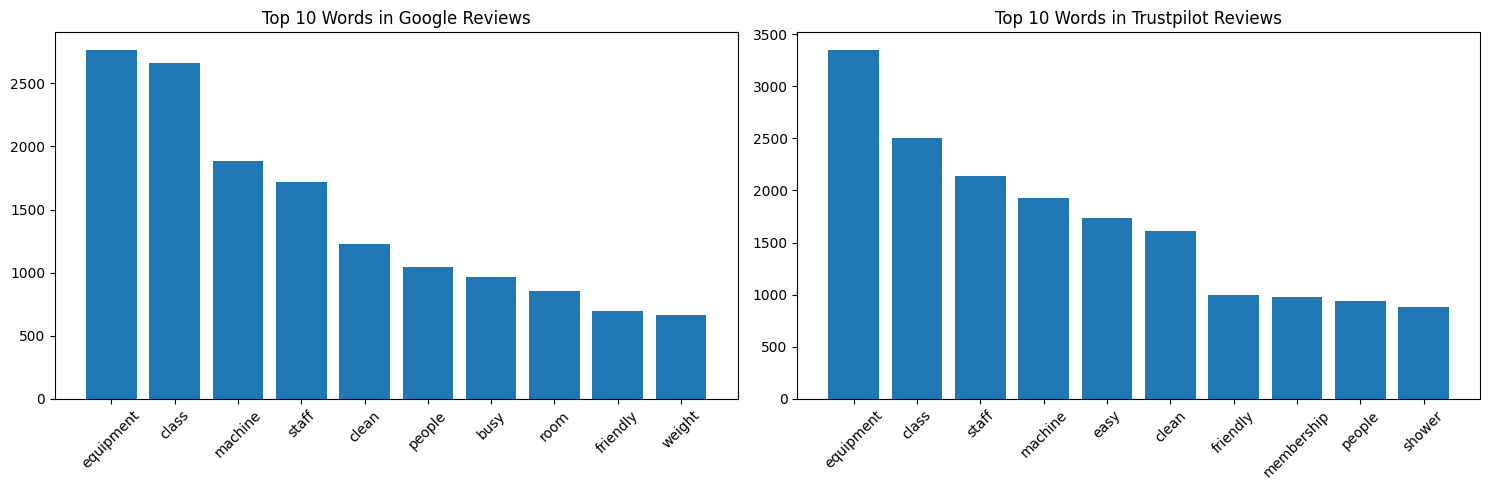

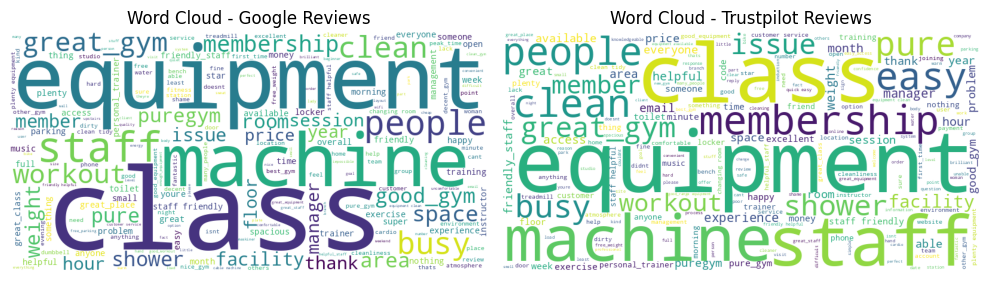

Number of negative reviews:
Google: 2785 (20.0% of total)
Trustpilot: 3543 (21.2% of total)


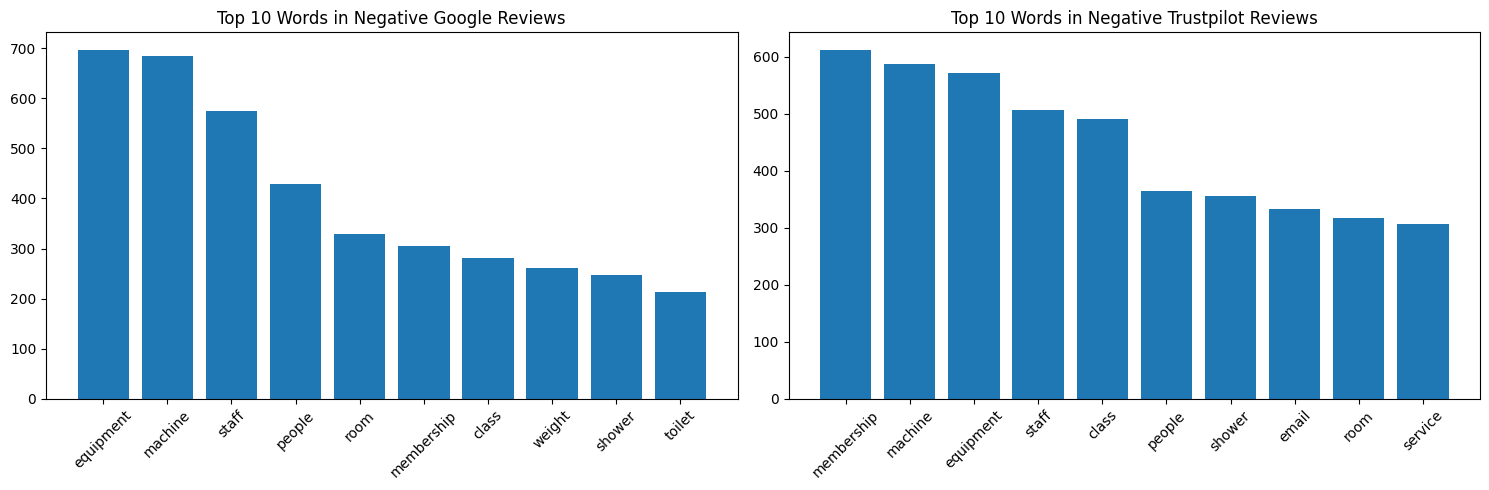

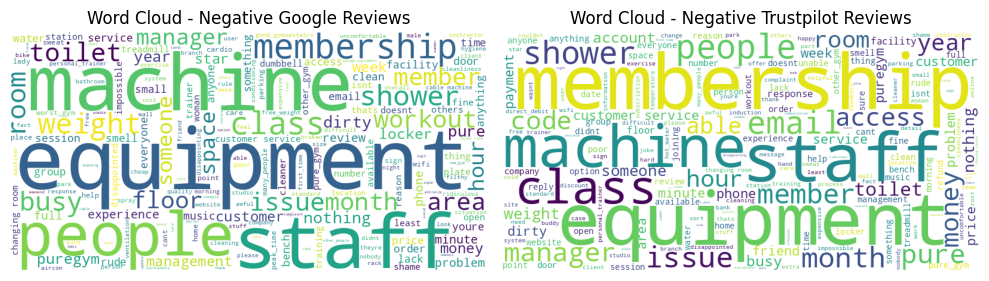


Most common words in negative Google reviews:
{'equipment': 697, 'machine': 684, 'staff': 575, 'people': 429, 'room': 329, 'membership': 306, 'class': 281, 'weight': 262, 'shower': 247, 'toilet': 213}

Most common words in negative Trustpilot reviews:
{'membership': 612, 'machine': 587, 'equipment': 571, 'staff': 506, 'class': 491, 'people': 364, 'shower': 355, 'email': 332, 'room': 317, 'service': 307}


In [ ]:
# Analyze locations
google_locs, trustpilot_locs, common_locs = analyze_locations(
    df_google_clean, df_trustpilot_clean
)

# Preprocess text in both datasets
df_google_clean["Processed_Comment"] = df_google_clean["Comment"].apply(
    lambda x: preprocess_text(x, lemmatizer)
)
df_trustpilot_clean["Processed_Review"] = df_trustpilot_clean["Review Content"].apply(
    lambda x: preprocess_text(x, lemmatizer)
)

# Tokenize processed text
df_google_clean["Tokenized_Comment"] = tokenize_text(
    df_google_clean["Processed_Comment"]
)
df_trustpilot_clean["Tokenized_Review"] = tokenize_text(
    df_trustpilot_clean["Processed_Review"]
)

# Get word frequencies
google_freq = get_word_frequencies(df_google_clean["Tokenized_Comment"])
trustpilot_freq = get_word_frequencies(df_trustpilot_clean["Tokenized_Review"])

# Print Top words in reviews
print("\nTop words in Google reviews:")
print(dict(google_freq.most_common(10)))

print("\nTop words in Trustpilot reviews:")
print(dict(trustpilot_freq.most_common(10)))

# Visualize word frequencies
plot_top_words(
    google_freq,
    trustpilot_freq,
    "Top 10 Words in Google Reviews",
    "Top 10 Words in Trustpilot Reviews",
)

# Create wordclouds
google_words = [
    word for tokens in df_google_clean["Tokenized_Comment"] for word in tokens
]
trustpilot_words = [
    word for tokens in df_trustpilot_clean["Tokenized_Review"] for word in tokens
]
create_wordclouds(
    google_words,
    "Word Cloud - Google Reviews",
    trustpilot_words,
    "Word Cloud - Trustpilot Reviews",
)

# Get and analyze negative reviews
negative_google, negative_trustpilot = get_negative_reviews(
    df_google_clean, df_trustpilot_clean
)

# Process negative reviews
negative_google_words = [
    word for tokens in negative_google["Tokenized_Comment"] for word in tokens
]
negative_trustpilot_words = [
    word for tokens in negative_trustpilot["Tokenized_Review"] for word in tokens
]

negative_google_freq = get_word_frequencies(negative_google["Tokenized_Comment"])
negative_trustpilot_freq = get_word_frequencies(negative_trustpilot["Tokenized_Review"])

# Visualize negative reviews
plot_top_words(
    negative_google_freq,
    negative_trustpilot_freq,
    "Top 10 Words in Negative Google Reviews",
    "Top 10 Words in Negative Trustpilot Reviews",
)

create_wordclouds(
    negative_google_words,
    "Word Cloud - Negative Google Reviews",
    negative_trustpilot_words,
    "Word Cloud - Negative Trustpilot Reviews",
)

# Print most common words in negative reviews
print("\nMost common words in negative Google reviews:")
print(dict(negative_google_freq.most_common(10)))

print("\nMost common words in negative Trustpilot reviews:")
print(dict(negative_trustpilot_freq.most_common(10)))

# Conducting initial topic modelling

In [ ]:
def prepare_common_location_reviews(negative_google, negative_trustpilot, common_locations):
    """Prepare and preprocess reviews from common locations"""
    # Filter reviews from common locations
    google_common = negative_google.loc[
        negative_google["Club's Name"].isin(common_locations)
    ].copy()
    trustpilot_common = negative_trustpilot.loc[
        negative_trustpilot["Location Name"].isin(common_locations)
    ].copy()

    # Combine processed reviews
    combined_reviews = google_common["Processed_Comment"].tolist() + trustpilot_common["Processed_Review"].tolist()

    # Clean and filter reviews
    preprocessed_reviews = [
        review
        for review in combined_reviews
        if review and isinstance(review, str) and review.strip()
    ]

    print(
        f"Total number of negative reviews from common locations: {len(preprocessed_reviews)}"
    )
    return preprocessed_reviews


def initialize_topic_model(device):
    """
    Initialize topic model with enhanced multilingual stopwords
    """

    # Initialize pipeline
    model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    embedder = pipeline(
        "feature-extraction",
        model=model_name,
        device=device,
        trust_remote_code=True
    )

    # Initialize vectorizer with multilingual stopwords
    vectorizer = CountVectorizer(
        stop_words=list(all_stops),
        min_df=1,
        max_df=0.99,
        token_pattern=r'(?u)\b\w+\w+\b'  # Allow for non-English characters
    )

    # UMAP configuration
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )

    # Initialize BERTopic
    topic_model = BERTopic(
        embedding_model=lambda x: embedder(x)[0],
        vectorizer_model=vectorizer,
        calculate_probabilities=True,
        nr_topics="auto",
        min_topic_size=10,
        n_gram_range=(1, 3),
        top_n_words=10,
        umap_model=umap_model,
        verbose=True
    )

    return topic_model, embedder


def analyze_topics(topic_model, preprocessed_reviews):
    """Analyze topics using BERTopic"""
    topics, probs = topic_model.fit_transform(preprocessed_reviews)
    topics_reduced_outliers = topic_model.reduce_outliers(preprocessed_reviews, topics, strategy="c-tf-idf")
    topic_info = topic_model.get_topic_info()

    return topics_reduced_outliers, probs, topic_info


def plot_topic_analysis(topic_model, topic_info, n_topics=10, n_words=5):
    """Create a combined visualization of all topic analysis plots"""
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 25))

    # 1. Topic Distribution Plot (top)
    ax1 = plt.subplot(3, 1, 1)
    top_topics = topic_info[topic_info["Topic"] != -1].head(10)
    ax = sns.barplot(x=range(len(top_topics)), y='Count', data=top_topics)

    max_height = top_topics['Count'].max()

    # Add words above bars
    for i in range(len(top_topics)):
        topic_num = top_topics.iloc[i]['Topic']
        count = top_topics.iloc[i]['Count']

        # Add document frequency on the bar
        plt.text(i,
                count/2,  # Middle of the bar
                f'{int(count):,}',  # Format with comma separators
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='white')  # White color for better visibility on bars

        words_weights = topic_model.get_topic(topic_num)[:5]
        words = [word for word, _ in words_weights]
        chunks = [words[i:i+2] for i in range(0, len(words), 2)]

        y_offset = top_topics.iloc[i]['Count'] + (max_height * 0.05)
        for chunk_idx, chunk in enumerate(chunks):
            text = ' | '.join(chunk)
            plt.text(i,
                    y_offset + (max_height * 0.05 * chunk_idx),
                    text,
                    fontsize=10,
                    ha='center',
                    va='bottom',)

    plt.ylim(0, max_height * 1.3)
    plt.title('Topic Distribution by Document Frequency', pad=20, fontsize=14)
    plt.xlabel('Topics', fontsize=12)
    plt.ylabel('Number of Documents', fontsize=12)
    plt.xticks(range(len(top_topics)), top_topics['Name'], rotation=45, ha='right')

    # 2. Top 2 Topics Word Distribution (middle)
    top_topics_2 = topic_info[topic_info["Topic"] != -1].head(2)

    # Plot first topic
    plt.subplot(3, 2, 3)
    topic = top_topics_2.iloc[0]['Topic']
    words, weights = zip(*topic_model.get_topic(topic))
    bars = sns.barplot(x=list(words), y=list(weights))
    for bar in bars.patches:
        bars.text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height(),
                 f'{bar.get_height():.3f}',
                 ha='center',
                 va='bottom')
    plt.title(f'Top Words in Topic {topic}', fontsize=12)
    plt.xlabel('Words', fontsize=10)
    plt.ylabel('Weight', fontsize=10)
    plt.xticks(rotation=45, ha='right')

    # Plot second topic
    plt.subplot(3, 2, 4)
    topic = top_topics_2.iloc[1]['Topic']
    words, weights = zip(*topic_model.get_topic(topic))
    bars = sns.barplot(x=list(words), y=list(weights))
    for bar in bars.patches:
        bars.text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height(),
                 f'{bar.get_height():.3f}',
                 ha='center',
                 va='bottom')
    plt.title(f'Top Words in Topic {topic}', fontsize=12)
    plt.xlabel('Words', fontsize=10)
    plt.xticks(rotation=45, ha='right')

    # 3. Topic Similarity Heatmap (bottom)
    plt.subplot(3, 1, 3)
    valid_topics = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()[:n_topics]

    # Create topic vectors
    topic_vectors = []
    all_words = set().union(*[dict(topic_model.get_topic(t)).keys() for t in valid_topics])

    for topic in valid_topics:
        topic_words = dict(topic_model.get_topic(topic))
        topic_vectors.append([topic_words.get(word, 0) for word in all_words])

    # Calculate similarity
    similarity_matrix = cosine_similarity(topic_vectors)

    # Create labels
    labels = [f"Topic {topic}\n({', '.join([w for w,_ in topic_model.get_topic(topic)[:3]])})"
             for topic in valid_topics]

    # Plot heatmap
    sns.heatmap(similarity_matrix,
                annot=True,
                cmap="YlOrRd",
                xticklabels=labels,
                yticklabels=labels,
                fmt=".2f")

    plt.title("Topic Similarity Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    # Adjust layout
    plt.tight_layout()
    plt.show()

Total number of negative reviews from common locations: 3893


config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/122 [00:00<?, ?it/s]

2024-11-23 14:21:25,735 - BERTopic - Embedding - Completed ✓
2024-11-23 14:21:25,736 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-23 14:21:53,542 - BERTopic - Dimensionality - Completed ✓
2024-11-23 14:21:53,544 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-23 14:21:54,177 - BERTopic - Cluster - Completed ✓
2024-11-23 14:21:54,179 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-23 14:21:54,312 - BERTopic - Representation - Completed ✓
2024-11-23 14:21:54,314 - BERTopic - Topic reduction - Reducing number of topics
2024-11-23 14:21:54,409 - BERTopic - Topic reduction - Reduced number of topics from 53 to 28


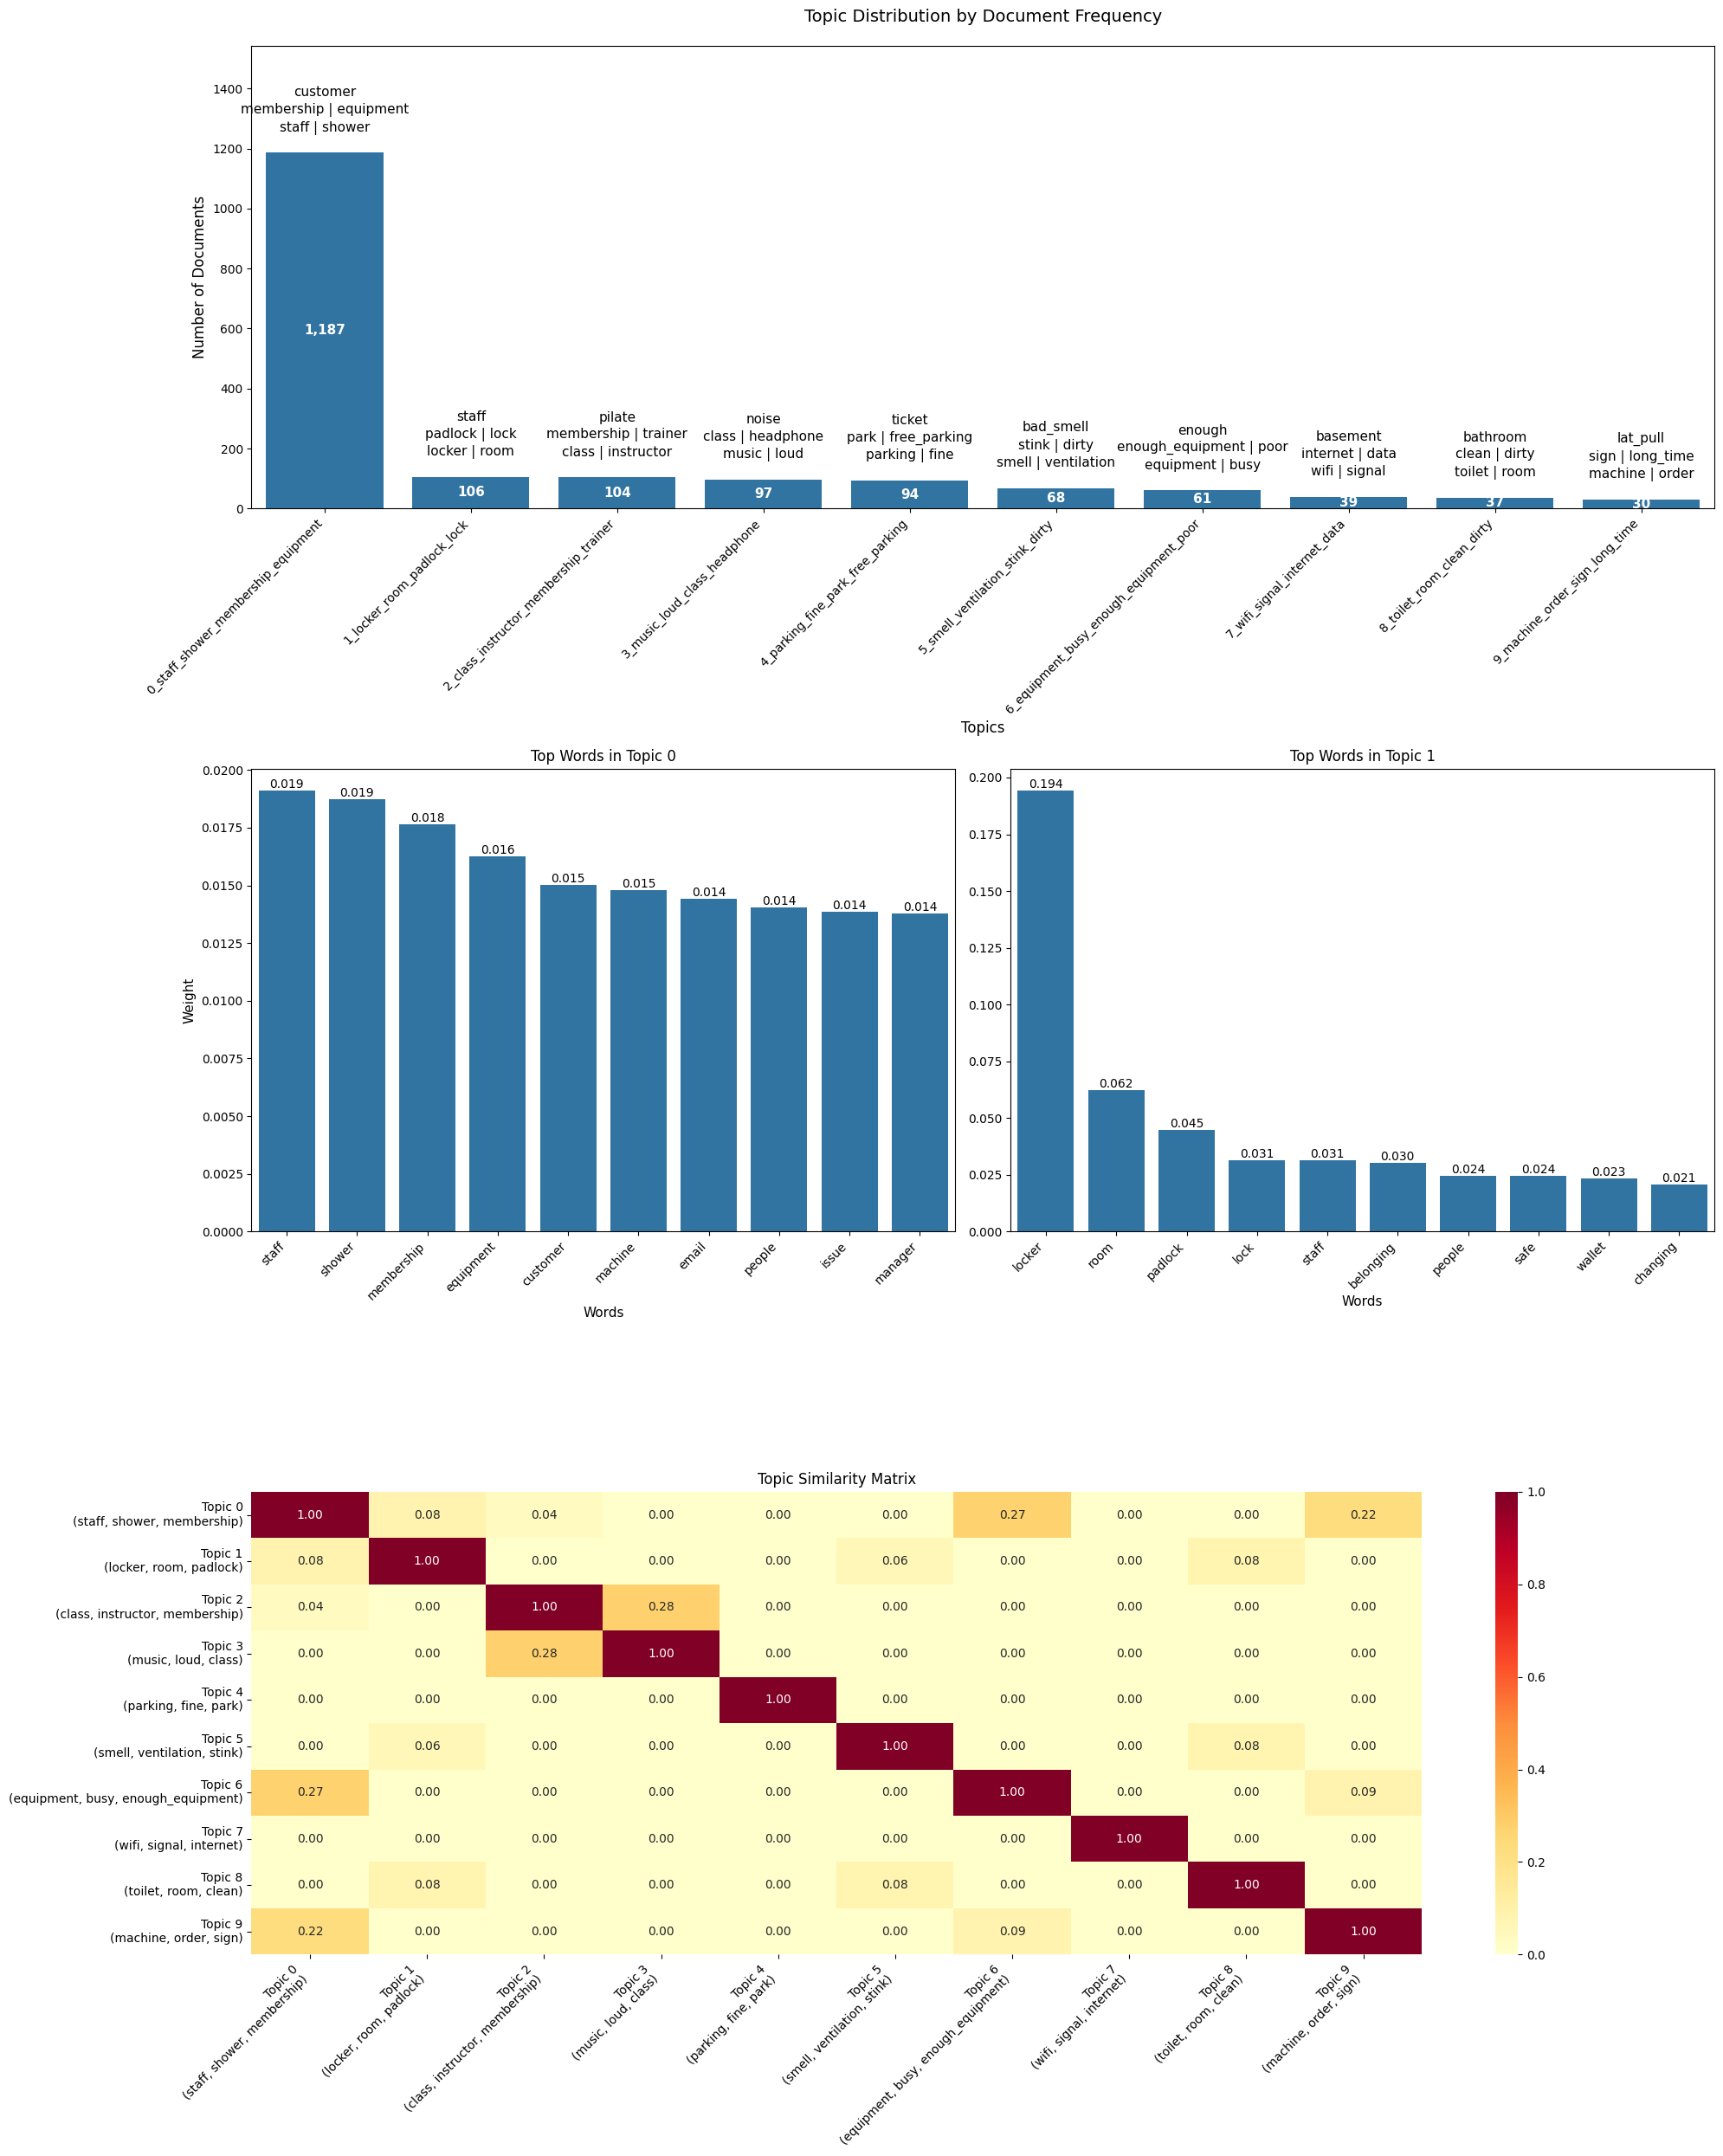

In [ ]:
# Prepare reviews from common locations
preprocessed_reviews = prepare_common_location_reviews(
    negative_google, negative_trustpilot, common_locs
)

# Initialize topic model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
topic_model, embedder = initialize_topic_model(device)

# Analyze topics
topics, probs, topic_info = analyze_topics(topic_model, preprocessed_reviews)

# Visualize topic summary
plot_topic_analysis(topic_model, topic_info)

# free up GPU VRAM for later use
embedder.model.cpu()
# Clear CUDA cache
torch.cuda.empty_cache()

### General theme of the top 10 clusters for negative reviews:



1.   Topic 0 (1187 docs): Customer membership, equipment, staff, shower facilities
2.   Topic 1 (326 docs): Staff interaction, padlock/locker room usage
3. Topic 2 (104 docs): Class management, membership, trainer interactions
4. Topic 3 (97 docs): Noise issues, headphone usage, music volume
5. Topic 4 (94 docs): Parking issues - tickets, fees, free parking availability
6. Topic 5 (68 docs): Cleanliness - smell, ventilation issues
7. Topic 6 (61 docs): Equipment availability and maintenance
8. Topic 7 (39 docs): Internet connectivity, wifi issues
9. Topic 8 (37 docs): Bathroom cleanliness and maintenance
10. Topic 9 (30 docs): Machine access, sign-in systems

# Performing further data investigation

In [ ]:
def analyze_top_negative_locations(negative_google, negative_trustpilot, n=20):
    """
    Analyze and visualize top locations with highest number of negative reviews
    from pre-filtered negative review dataframes

    Parameters:
    -----------
    negative_google : pd.DataFrame
        Pre-filtered dataframe containing only negative Google reviews
    negative_trustpilot : pd.DataFrame
        Pre-filtered dataframe containing only negative Trustpilot reviews
    n : int
        Number of top locations to display (default=20)

    Returns:
    --------
    tuple: (google_neg_loc, trustpilot_neg_loc) - DataFrames with top negative locations
    """

    # Calculate negative reviews by location
    google_neg_loc = (
        negative_google.groupby("Club's Name")
        .size()
        .reset_index(name="negative_count")
        .sort_values("negative_count", ascending=False)
        .head(n)
    )

    trustpilot_neg_loc = (
        negative_trustpilot.groupby("Location Name")
        .size()
        .reset_index(name="negative_count")
        .sort_values("negative_count", ascending=False)
        .head(n)
    )

    # Calculate percentages of total negative reviews
    google_total = google_neg_loc['negative_count'].sum()
    trustpilot_total = trustpilot_neg_loc['negative_count'].sum()

    google_neg_loc['percentage'] = (google_neg_loc['negative_count'] / google_total * 100).round(2)
    trustpilot_neg_loc['percentage'] = (trustpilot_neg_loc['negative_count'] / trustpilot_total * 100).round(2)

    # Print formatted results
    print("\n=== Top 20 Locations with Most Negative Reviews ===")

    print(f"\nGoogle Reviews (Total {google_total}):")
    print("=" * 80)
    print(f"{'Location':<40} {'Count':<10} {'% of Total':<10}")
    print("-" * 80)
    for _, row in google_neg_loc.iterrows():
        print("{:<40} {:<10} {}%".format(row["Club's Name"], row['negative_count'], row['percentage']))

    print(f"\nTrustpilot Reviews (Total {trustpilot_total}):")
    print("=" * 80)
    print(f"{'Location':<40} {'Count':<10} {'% of Total':<10}")
    print("-" * 80)
    for _, row in trustpilot_neg_loc.iterrows():
        print(f"{row['Location Name']:<40} {row['negative_count']:<10} {row['percentage']}%")

    # common locations
    google_locations = set(google_neg_loc["Club's Name"])
    trustpilot_locations = set(trustpilot_neg_loc["Location Name"])
    common_locations = google_locations.intersection(trustpilot_locations)
    print(f"\nCommon locations: {list(common_locations)}")

    return google_neg_loc, trustpilot_neg_loc


def merge_review_datasets(df_google, df_trustpilot):
    """Merge Google and Trustpilot datasets based on location"""
    # Count reviews per location for each dataset
    google_counts = (
        df_google.groupby("Club's Name").size().reset_index(name="Google_Reviews")
    )

    trustpilot_counts = (
        df_trustpilot.groupby("Location Name")
        .size()
        .reset_index(name="Trustpilot_Reviews")
    )

    # Merge the counts
    merged_df = pd.merge(
        google_counts,
        trustpilot_counts,
        left_on="Club's Name",
        right_on="Location Name",
        how="outer",
    )

    # Clean up and calculate totals
    merged_df = merged_df.fillna(0)
    merged_df["Total_Reviews"] = (
        merged_df["Google_Reviews"] + merged_df["Trustpilot_Reviews"]
    )
    merged_df = merged_df.sort_values("Total_Reviews", ascending=False)

    # Use consistent location name
    merged_df["Location"] = merged_df["Club's Name"].fillna(merged_df["Location Name"])
    merged_df = merged_df[
        ["Location", "Trustpilot_Reviews", "Google_Reviews", "Total_Reviews"]
    ]

    return merged_df


def analyze_top_30_locations(df_merged, df_google, df_trustpilot):
    """Analyze reviews for top 30 locations"""
    top_locations = df_merged.head(30)["Location"].tolist()

    # Get reviews for top locations
    google_reviews = df_google[df_google["Club's Name"].isin(top_locations)][
        "Tokenized_Comment"
    ].tolist()
    trustpilot_reviews = df_trustpilot[
        df_trustpilot["Location Name"].isin(top_locations)
    ]["Processed_Review"].tolist()

    # Get word frequencies
    google_freq = get_word_frequencies(df_google[df_google["Club's Name"].isin(top_locations)][
        "Tokenized_Comment"
    ].tolist())
    trustpilot_freq = get_word_frequencies(df_trustpilot[
        df_trustpilot["Location Name"].isin(top_locations)
    ]["Tokenized_Review"].tolist())

    # Visualize word frequencies
    plot_top_words(
        google_freq,
        trustpilot_freq,
        'Top 10 Words in Google Reviews',
        'Top 10 Words in Trustpilot Reviews'
    )

    # Create wordclouds
    google_words = [word for tokens in df_google[df_google["Club's Name"].isin(top_locations)][
        "Tokenized_Comment"
    ] for word in tokens]
    trustpilot_words = [word for tokens in df_trustpilot[
        df_trustpilot["Location Name"].isin(top_locations)
    ]["Tokenized_Review"] for word in tokens]
    create_wordclouds(
        google_words,
        'Word Cloud - Google Reviews',
        trustpilot_words,
        'Word Cloud - Trustpilot Reviews'
    )

    # Combine processed reviews
    google_reviews = df_google[df_google["Club's Name"].isin(top_locations)][
        "Processed_Comment"
    ].tolist()
    trustpilot_reviews = df_trustpilot[
        df_trustpilot["Location Name"].isin(top_locations)
    ]["Processed_Review"].tolist()

    # Clean and filter reviews
    combined_reviews = [review for review in (google_reviews + trustpilot_reviews)
                          if review and isinstance(review, str) and review.strip()]

    # Initialize and run BERTopic
    topic_model, embedder = initialize_topic_model(device)
    topics, probs, topic_info = analyze_topics(topic_model, combined_reviews)

    return topic_model, embedder, topics, probs, topic_info


def compare_topic_models(model1_info, model2_info):
    """Compare results from two different BERTopic runs"""
    print("\nTopic Model Comparison:")
    print("\nFirst Run Top Topics:")
    print(model1_info[model1_info["Topic"] != -1][["Topic", "Count", "Name"]].head())
    print("\nSecond Run Top Topics:")
    print(model2_info[model2_info["Topic"] != -1][["Topic", "Count", "Name"]].head())


=== Top 20 Locations with Most Negative Reviews ===

Google Reviews (Total 438):
Location                                 Count      % of Total
--------------------------------------------------------------------------------
London Stratford                         59         13.47%
London Canary Wharf                      26         5.94%
London Woolwich                          26         5.94%
London Enfield                           25         5.71%
London Swiss Cottage                     24         5.48%
London Palmers Green                     22         5.02%
Birmingham City Centre                   21         4.79%
London Leytonstone                       21         4.79%
New Barnet                               20         4.57%
Peterborough Serpentine                  19         4.34%
Wakefield                                19         4.34%
Bradford Thornbury                       19         4.34%
London Hoxton                            18         4.11%
London Seven Sister

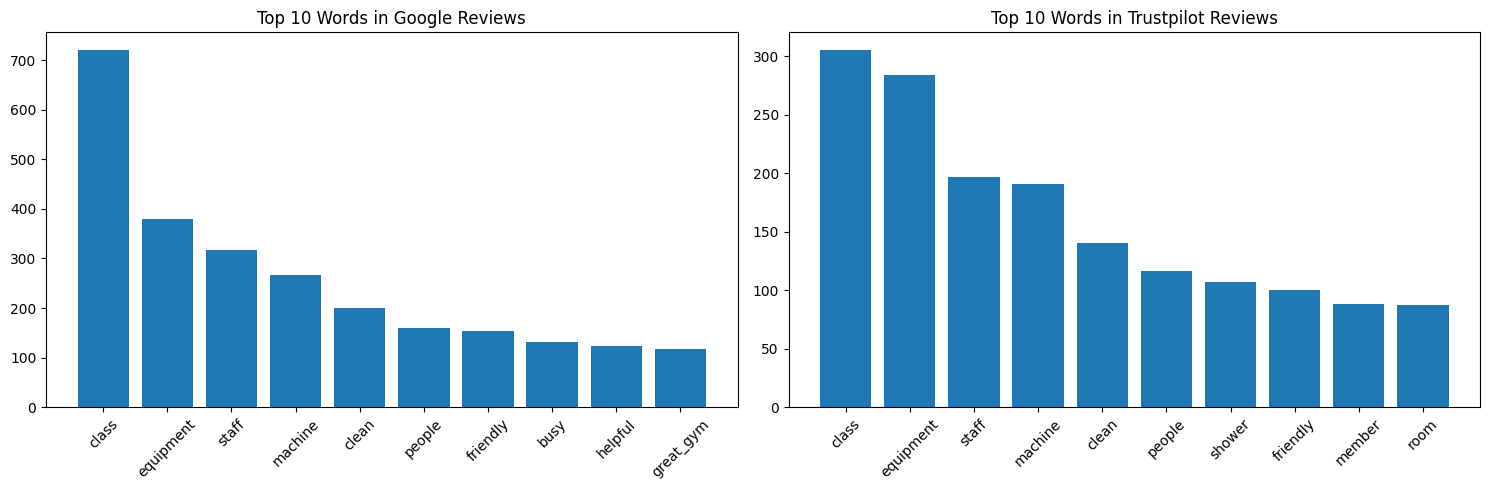

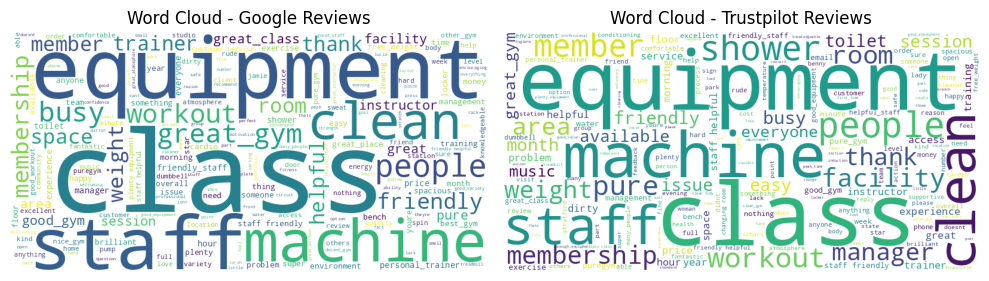

2024-11-23 14:46:45,941 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/113 [00:00<?, ?it/s]

2024-11-23 14:46:47,610 - BERTopic - Embedding - Completed ✓
2024-11-23 14:46:47,611 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-23 14:47:06,403 - BERTopic - Dimensionality - Completed ✓
2024-11-23 14:47:06,405 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-23 14:47:07,104 - BERTopic - Cluster - Completed ✓
2024-11-23 14:47:07,106 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-23 14:47:07,214 - BERTopic - Representation - Completed ✓
2024-11-23 14:47:07,216 - BERTopic - Topic reduction - Reducing number of topics
2024-11-23 14:47:07,301 - BERTopic - Topic reduction - Reduced number of topics from 69 to 48


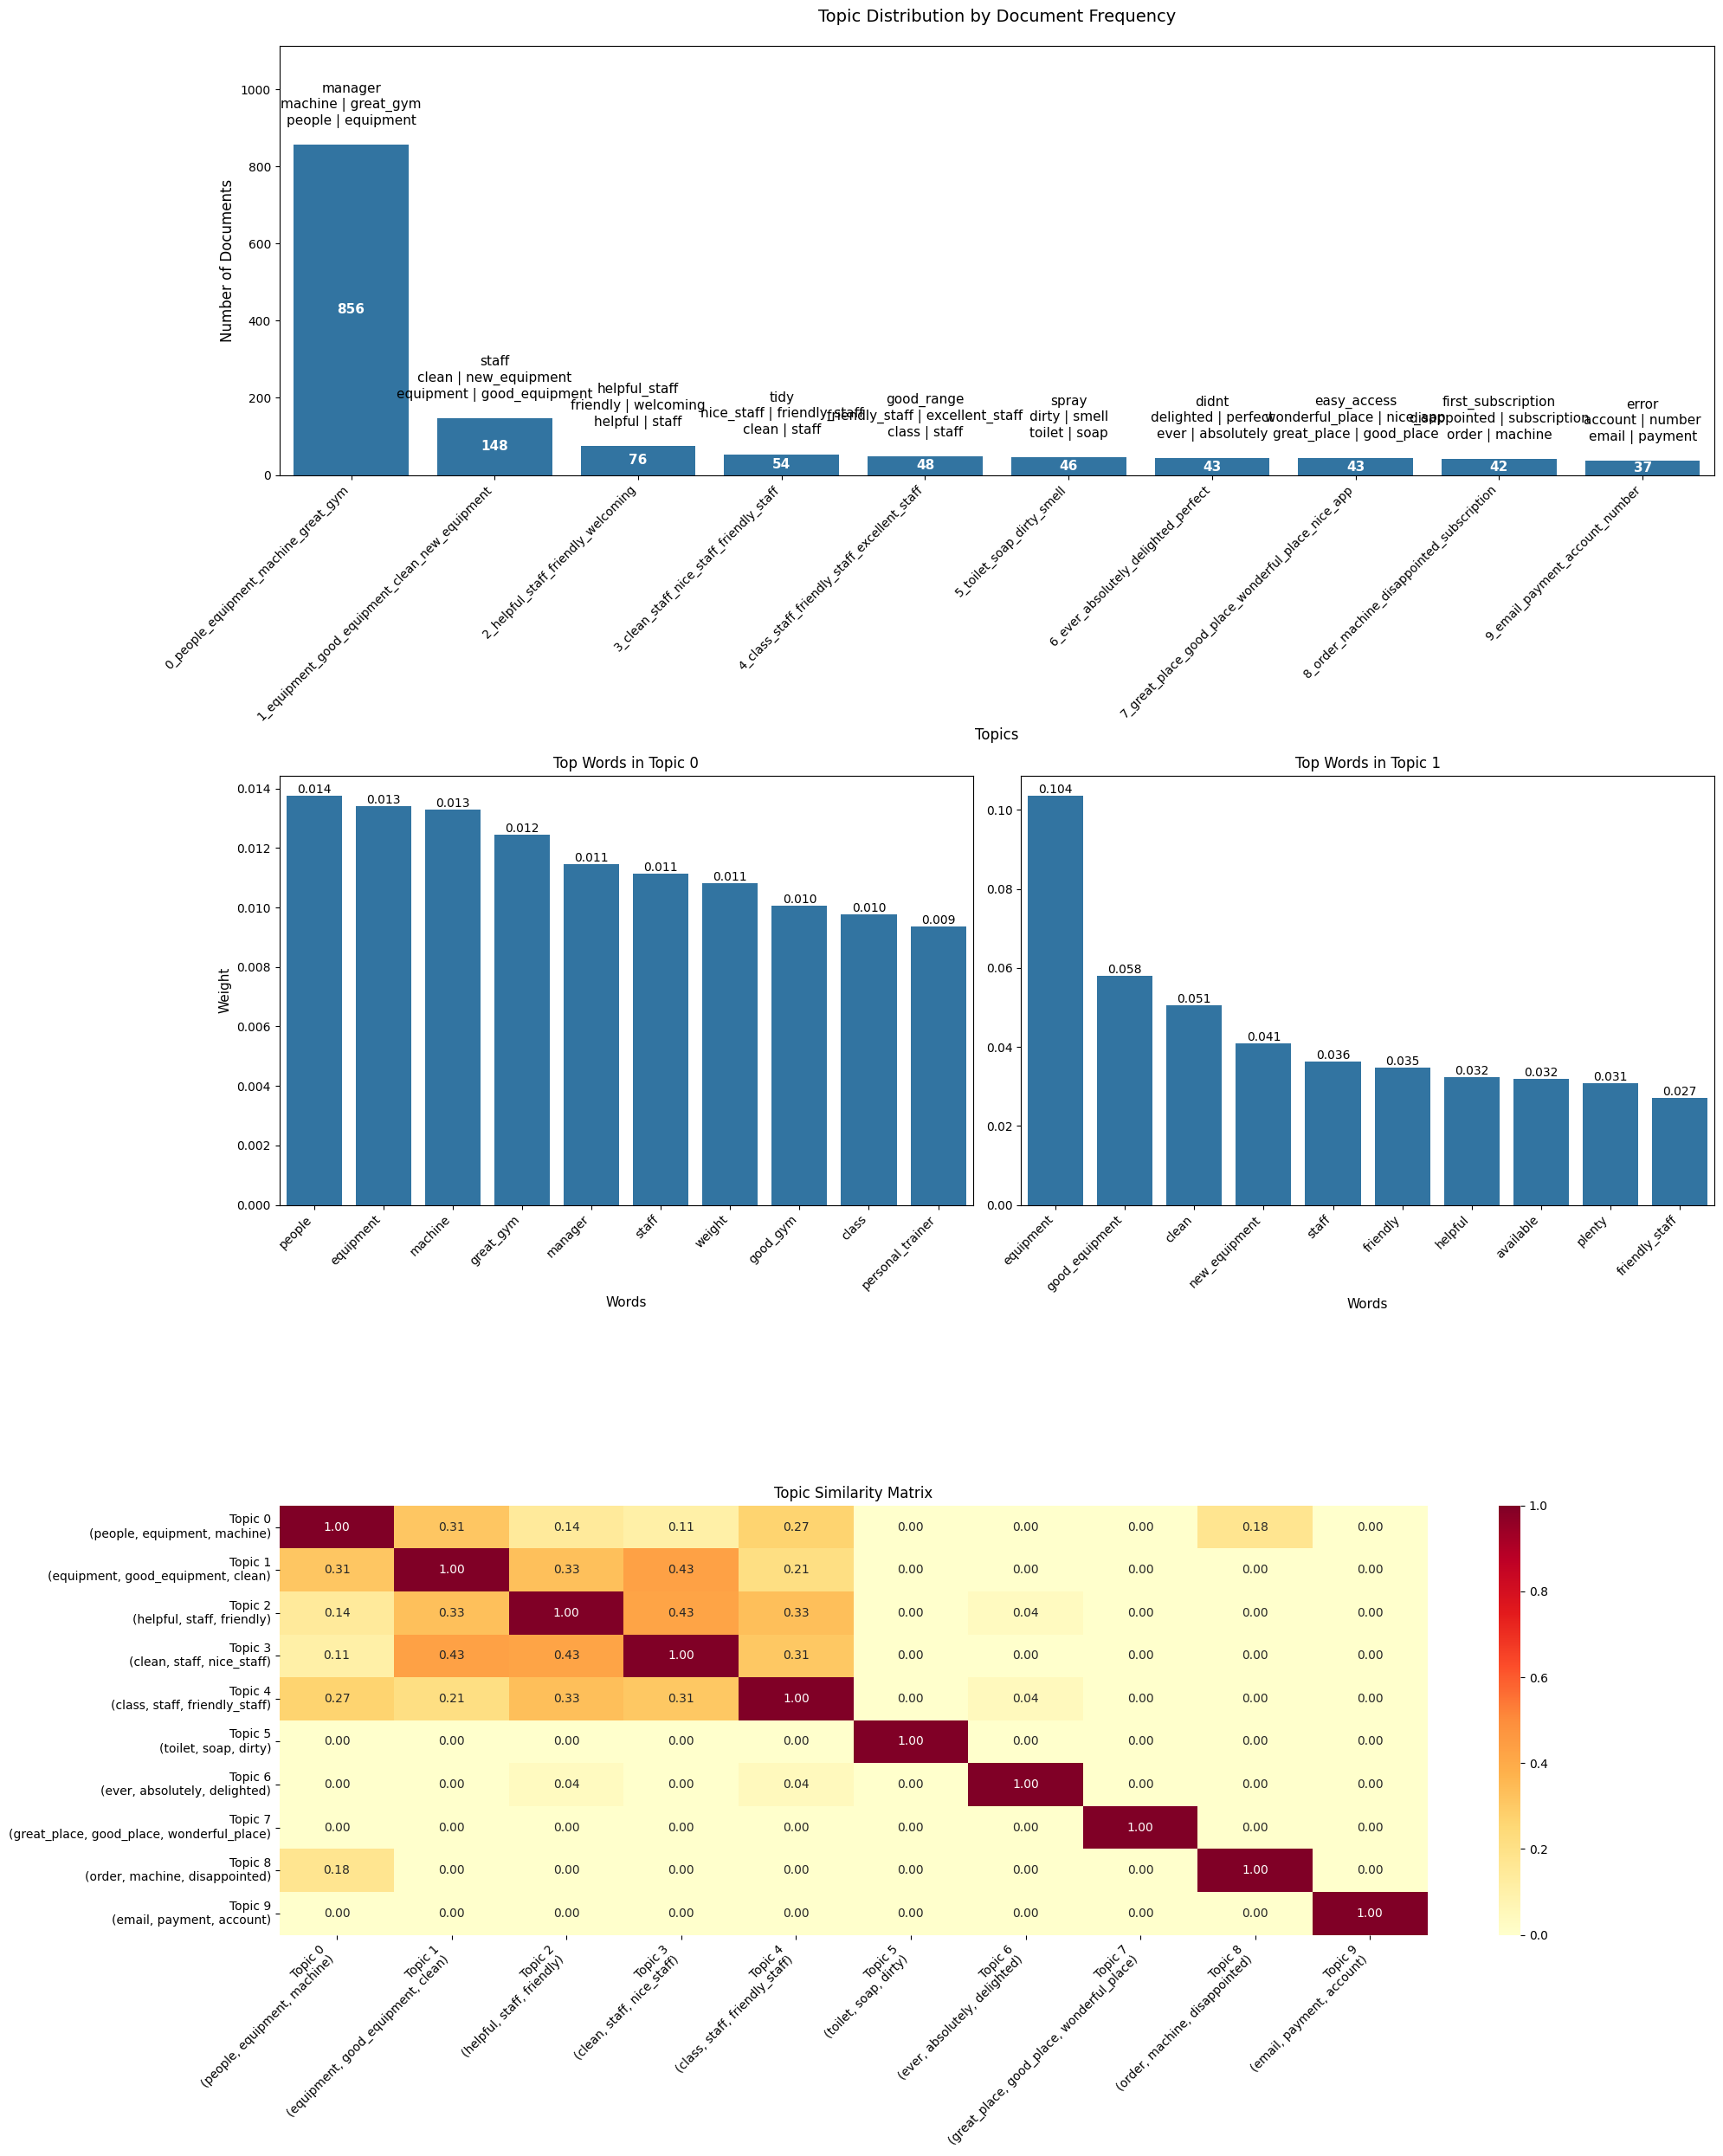


Topic Model Comparison:

First Run Top Topics:
   Topic  Count                                   Name
1      0   1187    0_staff_shower_membership_equipment
2      1    106             1_locker_room_padlock_lock
3      2    104  2_class_instructor_membership_trainer
4      3     97           3_music_loud_class_headphone
5      4     94       4_parking_fine_park_free_parking

Second Run Top Topics:
   Topic  Count                                            Name
1      0    856            0_people_equipment_machine_great_gym
2      1    148  1_equipment_good_equipment_clean_new_equipment
3      2     76              2_helpful_staff_friendly_welcoming
4      3     54         3_clean_staff_nice_staff_friendly_staff
5      4     48    4_class_staff_friendly_staff_excellent_staff


In [ ]:
# Get top 20 locations with negative reviews
top_google_neg, top_trustpilot_neg = analyze_top_negative_locations(
    negative_google, negative_trustpilot, n=20
)

# Merge datasets and get review counts
merged_locations = merge_review_datasets(df_google_clean, df_trustpilot_clean)
print("\nMerged Location Statistics:")
pd.set_option('display.width', 180)
print(merged_locations.head(len(merged_locations)))

# Analyze top 30 locations
top_topic_model, embedder, top_topics, top_probs, top_topic_info  = analyze_top_30_locations(
    merged_locations, df_google_clean, df_trustpilot_clean
)

# Visualize topic summary
plot_topic_analysis(top_topic_model, top_topic_info)

# Compare with previous BERTopic results
compare_topic_models(topic_info, top_topic_info)

# free up GPU VRAM for later use
embedder.model.cpu()
# Clear CUDA cache
torch.cuda.empty_cache()

**List out the top 20 locations with the highest number of negative reviews. Do this separately for Google and Trustpilot's reviews, and comment on the result. Are the locations roughly similar in both data sets?**


- London dominates with 8-11 locations in top 20 for both platforms

- Key matches between platforms: London Enfield, Stratford, Swiss Cottage, Bermondsey, Hayes, and Seven Sisters

- Notable presence of major cities (Birmingham, Manchester)


- Leicester Walnut Street: Highest Trustpilot complaints (12.76%) but absent from Google top 20

- London Stratford: Leads Google reviews (13.47%) but ranks 4th on Trustpilot (5.61%)

- Birmingham City Centre shows consistent issues across platforms

- Google: 438 total negative reviews, Trustpilot: 392 total negative reviews

- Top locations account for 3.5-13.5% of complaints each


Merged Data Insights:

- Elkridge and Springfield show high Google-only review counts
- London Park Royal has significant cross-platform presence
- Manchester Market Street shows substantial combined feedback

This geographic distribution suggests systemic issues in London locations while highlighting platform-specific reporting patterns.

**For the top 30 locations, redo the word frequency and word cloud. Comment on the results, and highlight if the results are different from the first run.**
 1. Volume Differences:
    - All locations: Google (2700+ mentions), Trustpilot (3300+ mentions)
    - Top 30: Google (700+ mentions), Trustpilot (300+ mentions)
    - ~75-80% of reviews come from locations outside top 30

 2. Word Priority Changes:
    - All: 'equipment' leads in both platforms
    - Top 30: 'class' becomes dominant term
    - 'great_gym' more prominent in top 30 locations

 3. Term Distribution:
    - All: More facility/equipment focused
    - Top 30: More balanced between service and facilities

**Key Differences in Top 30 Locations All reviews vs All Locations Negative Reviews**:


 - Topic 0 (856 docs): Higher focus on manager interaction and equipment
 - Topic 1 (148 docs): More emphasis on staff quality and equipment maintenance
 - Topic 2 (76 docs): Strong customer service themes
 - Topic 3 (54 docs): Focus on class experience
 - Topic 4 (48 docs): Staff interaction and class quality

Notable: More positive terms present ('great', 'helpful', 'friendly')

Similarity matrix shows stronger interconnections between topics

# Conduct Emotion Analysis

In [ ]:
def setup_emotion_classifier(device):
    """Setup the BERT emotion classifier"""
    classifier = pipeline(
        "text-classification",
        model="bhadresh-savani/bert-base-uncased-emotion",
        device=device,
        max_length=512,
        truncation=True
    )

    # Test with example
    example = "I'm really happy with the service!"
    result = classifier(example)
    print("\nEmotion Classifier Test:")
    print(f"Example text: {example}")
    print(f"Classification: {result}")

    return classifier


def classify_emotions(texts, classifier, batch_size=32):
    """Classify emotions in texts using batched processing"""
    emotions = []

    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        # Filter out non-string or empty entries
        batch = [text for text in batch if isinstance(text, str) and text.strip()]
        if batch:
            results = classifier(batch)
            emotions.extend([result["label"] for result in results])

    return emotions


def analyze_review_emotions(df_google, df_trustpilot, classifier):
    """Analyze emotions in both the datasets"""
    # Classify emotions
    print("\nClassifying emotions in Google reviews...")
    google_emotions = classify_emotions(df_google["Comment"].tolist(), classifier)
    print("Classifying emotions in Trustpilot reviews...")
    trustpilot_emotions = classify_emotions(
        df_trustpilot["Review Content"].tolist(), classifier
    )

    # Add emotion classifications to dataframes
    df_google["Emotion"] = google_emotions
    df_trustpilot["Emotion"] = trustpilot_emotions

    return df_google, df_trustpilot


def plot_emotion_distribution_all_reviews(google_emotions, trustpilot_emotions):
   """Plot emotion distribution for both datasets in a single comparative bar chart"""
   plt.figure(figsize=(12, 6))

   # Convert to pandas Series and get counts
   google_counts = pd.Series(google_emotions).value_counts()
   trustpilot_counts = pd.Series(trustpilot_emotions).value_counts()

   # Create DataFrame with both datasets
   df_combined = pd.DataFrame({
       'Google': google_counts,
       'Trustpilot': trustpilot_counts
   }).fillna(0)  # Fill NaN with 0 for any missing emotions

   # Plot bars
   ax = df_combined.plot(
       kind='bar',
       width=0.8,
       color=['#2ecc71', '#e74c3c'],  # Green for Google, Red for Trustpilot
       figsize=(12, 6)
   )

   # Customize the plot
   plt.title('Emotion Distribution Comparison: Google vs Trustpilot Reviews',
            fontsize=14,
            pad=20)
   plt.xlabel('Emotions', fontsize=12)
   plt.ylabel('Number of Reviews', fontsize=12)

   # Rotate x-axis labels
   plt.xticks(rotation=45, ha='right')

   # Add legend
   plt.legend(title='Platform',
             bbox_to_anchor=(1.05, 1),
             loc='upper left')

   # Add value labels on top of bars
   for p in ax.patches:
       ax.annotate(
           int(p.get_height()),
           (p.get_x() + p.get_width()/2, p.get_height()),
           ha='center',
           va='bottom'
       )

   # Adjust layout to prevent label cutoff
   plt.tight_layout()
   plt.show()


def get_angry_reviews(google_emotions, trustpilot_emotions):
    """Extract reviews where anger is the primary emotion"""
    google_angry = google_emotions[google_emotions["Emotion"] == "anger"]
    trustpilot_angry = trustpilot_emotions[trustpilot_emotions["Emotion"] == "anger"]
    angry_reviews = pd.concat(
        [google_angry["Comment"], trustpilot_angry["Review Content"]]
    ).tolist()

    print(f"\nTotal angry reviews found: {len(angry_reviews)}")
    return angry_reviews


def plot_negative_emotion_distribution(google_emotions, trustpilot_emotions):
    """
    Create a bar plot showing the distribution of negative emotions across both datasets

    Parameters:
    google_emotions (DataFrame): DataFrame containing Google reviews with emotions
    trustpilot_emotions (DataFrame): DataFrame containing Trustpilot reviews with emotions
    """
    # Define negative emotions
    negative_emotions = ['anger', 'disgust', 'sadness', 'fear']

    # Combine emotions from both datasets and filter for negative only
    combined_emotions = pd.concat([
        google_emotions["Emotion"],
        trustpilot_emotions["Emotion"]
    ])
    negative_only = combined_emotions[combined_emotions.isin(negative_emotions)]

    # Get counts for negative emotions
    emotion_counts = negative_only.value_counts()

    # Create bar plot
    plt.figure(figsize=(6, 4))
    emotion_counts.plot(kind="bar", color='#FF6B6B')

    # Customize plot
    plt.title("Distribution of Negative Emotions in Reviews")
    plt.xticks(rotation=45)
    plt.ylabel("Number of Reviews")
    plt.xlabel("Emotion")

    plt.tight_layout()
    plt.show()

    # Print total negative reviews
    total_negative = len(negative_only)
    print(f"\nTotal negative reviews: {total_negative:,}")


def run_topic_modeling_angry_reviews(angry_reviews, device):
    """Run topic modeling on angry reviews"""
    # Preprocess angry reviews
    preprocessed_angry = [
        preprocess_text(review, lemmatizer)
        for review in angry_reviews
        if isinstance(review, str)
    ]
    preprocessed_angry = [review for review in preprocessed_angry if review.strip()]

    # Run BERTopic
    print("\nAnalyzing topics in angry reviews...")
    topic_model, embedder = initialize_topic_model(device)
    topics, probs, topic_info = analyze_topics(topic_model, preprocessed_angry)

    return topic_model, embedder, topics, probs, topic_info

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Emotion Classifier Test:
Example text: I'm really happy with the service!
Classification: [{'label': 'joy', 'score': 0.9984667301177979}]

Classifying emotions in Google reviews...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Classifying emotions in Trustpilot reviews...


<Figure size 1200x600 with 0 Axes>

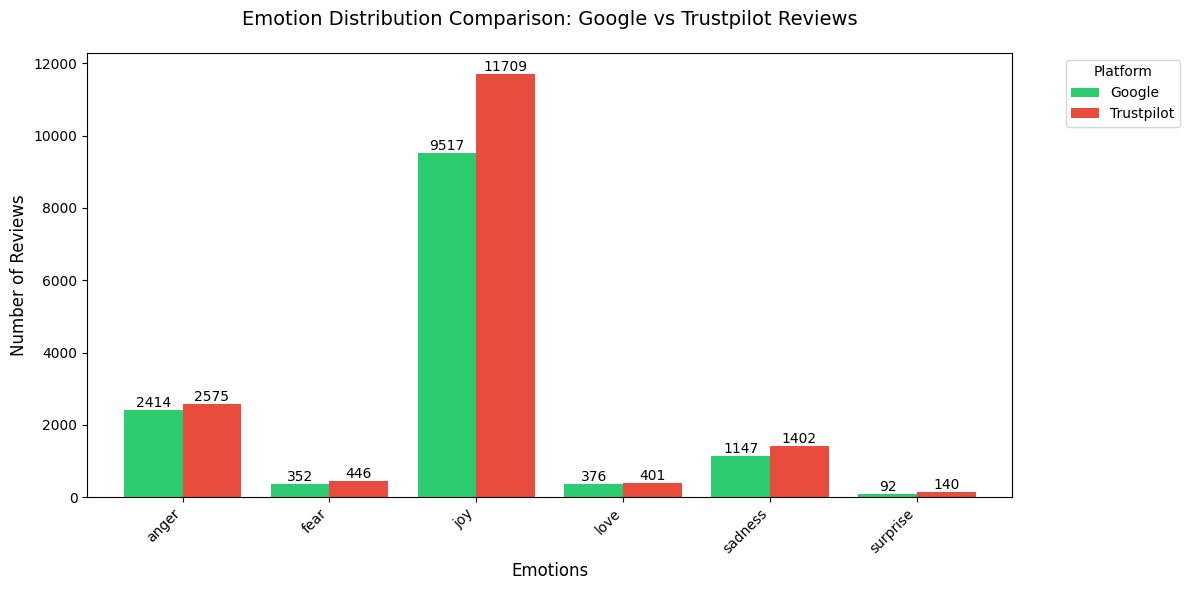

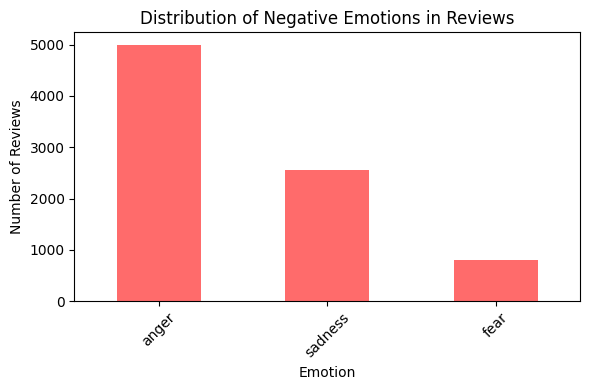


Total negative reviews: 8,336

Total angry reviews found: 4989

Analyzing topics in angry reviews...


2024-11-23 02:39:37,328 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/151 [00:00<?, ?it/s]

2024-11-23 02:39:42,027 - BERTopic - Embedding - Completed ✓
2024-11-23 02:39:42,028 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-23 02:40:07,986 - BERTopic - Dimensionality - Completed ✓
2024-11-23 02:40:07,988 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-23 02:40:09,082 - BERTopic - Cluster - Completed ✓
2024-11-23 02:40:09,083 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-23 02:40:09,218 - BERTopic - Representation - Completed ✓
2024-11-23 02:40:09,219 - BERTopic - Topic reduction - Reducing number of topics
2024-11-23 02:40:09,318 - BERTopic - Topic reduction - Reduced number of topics from 68 to 22


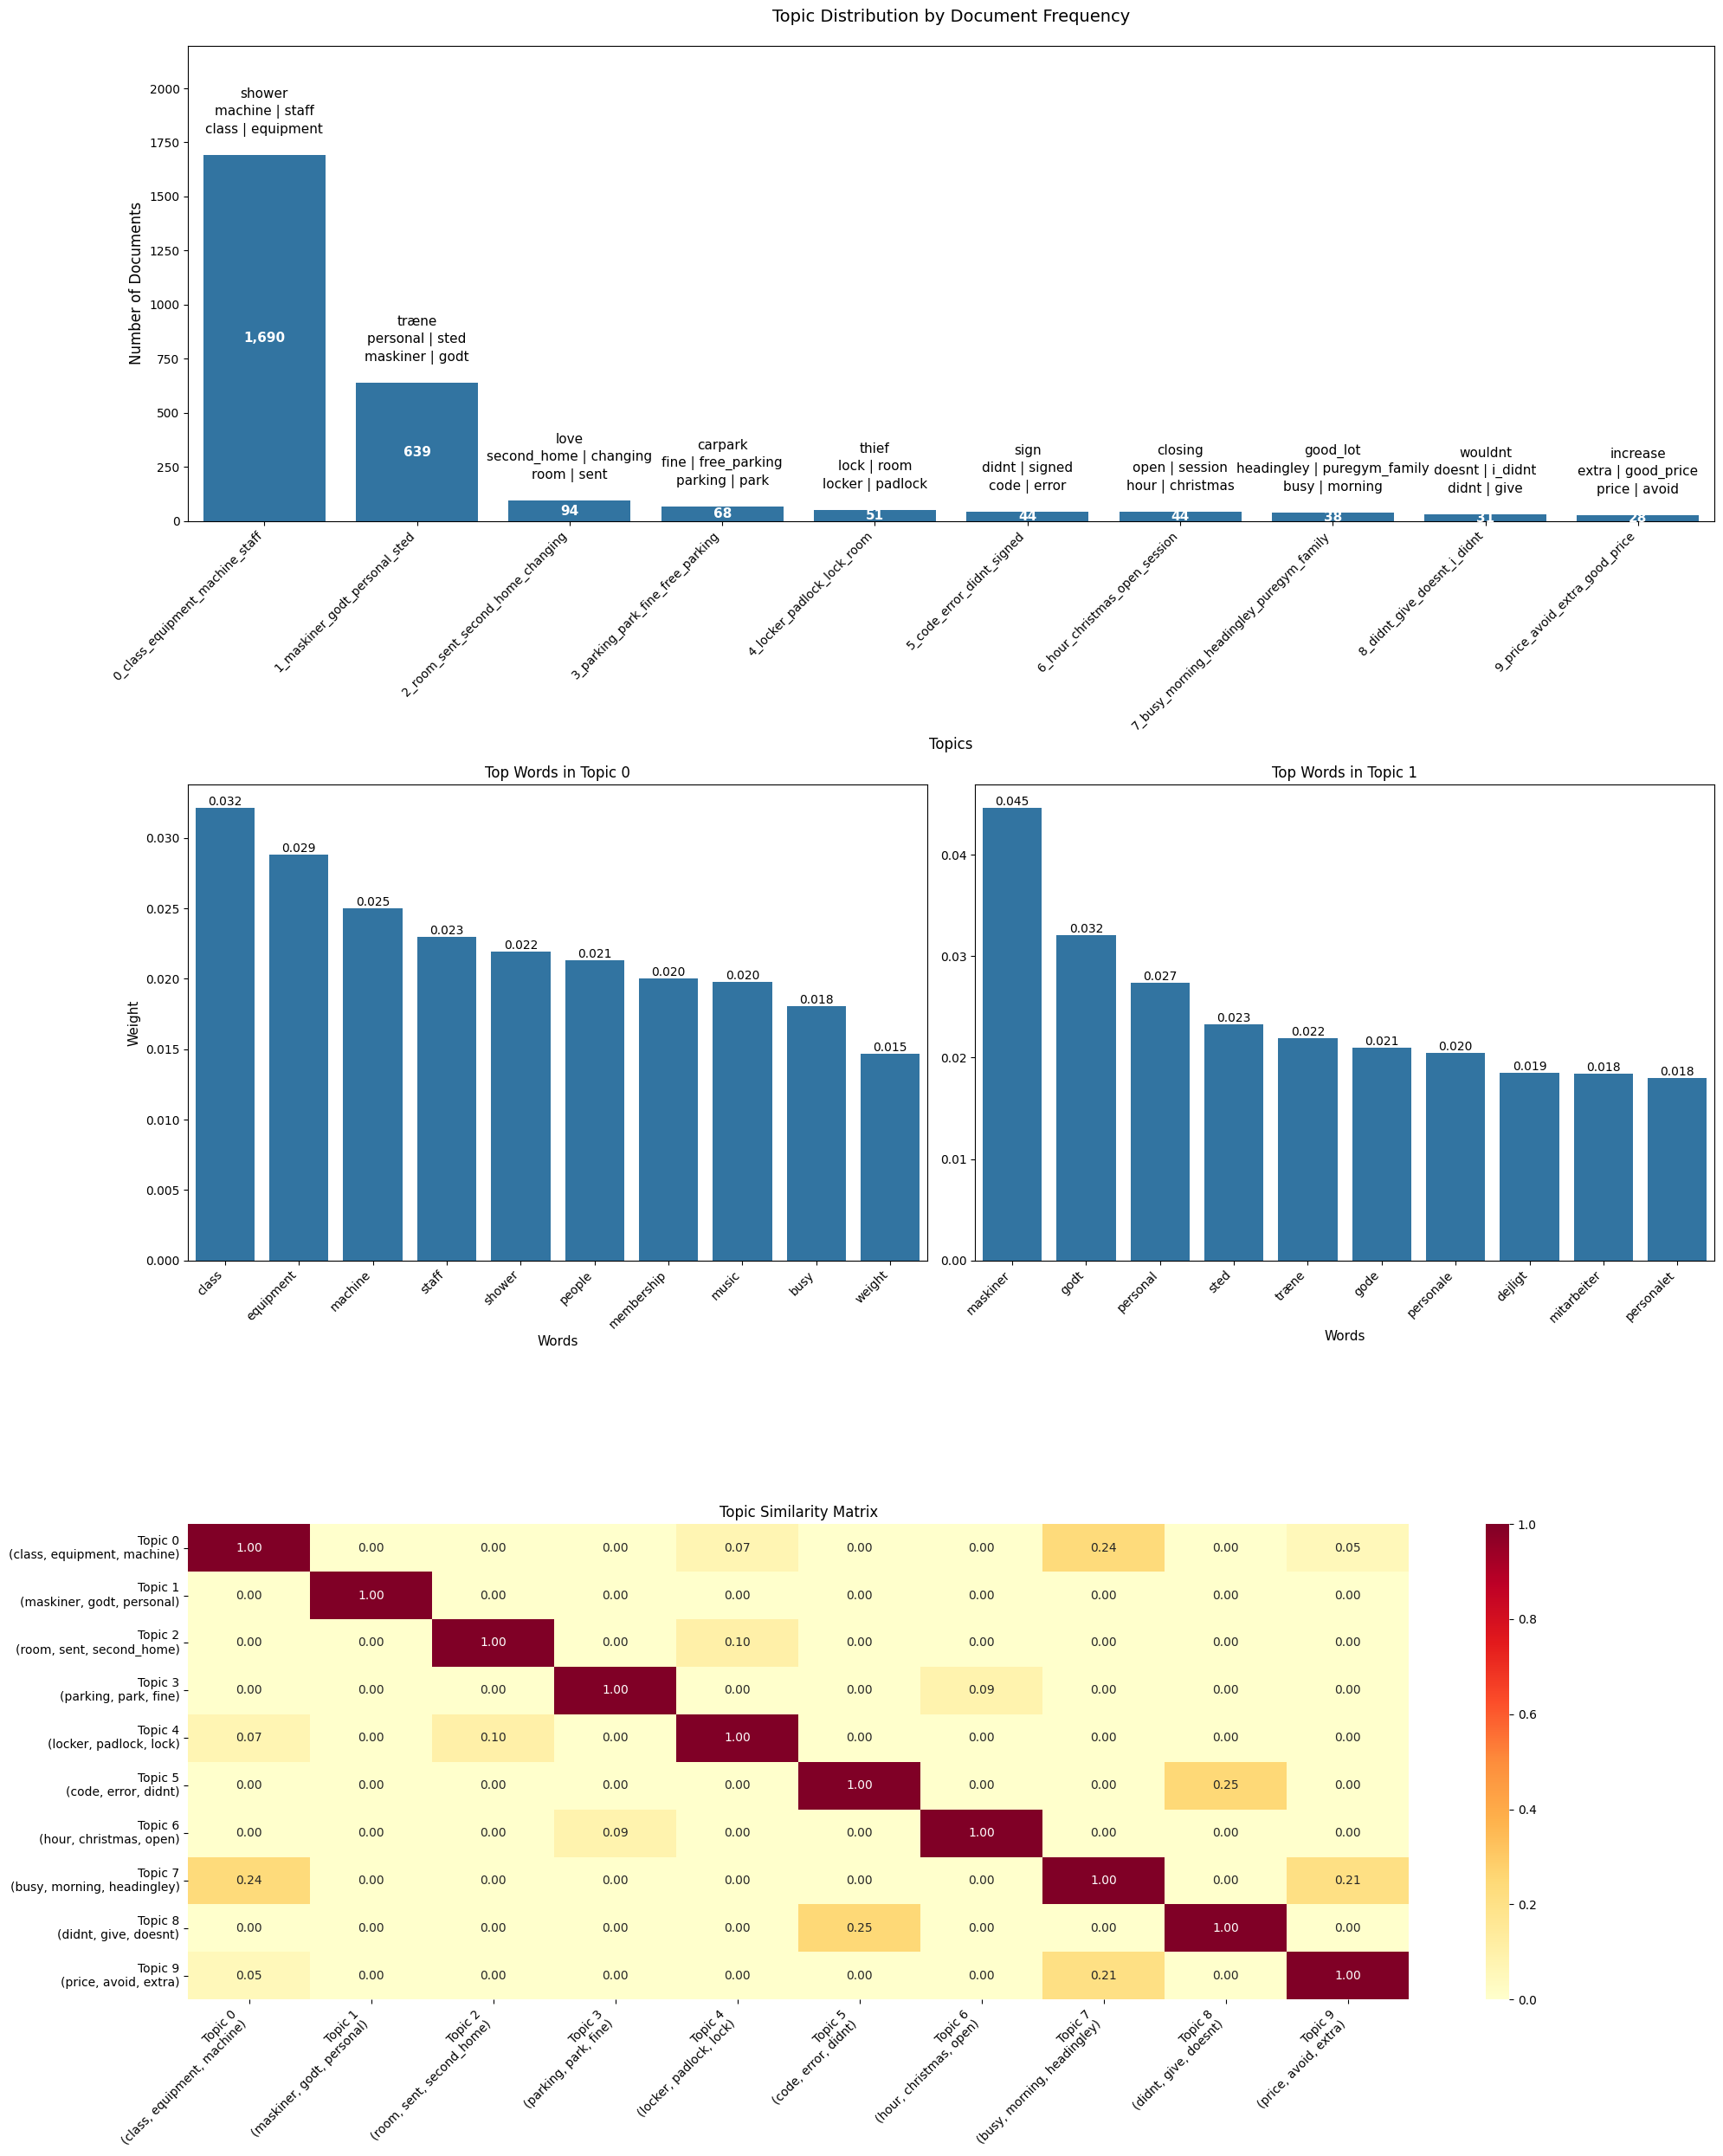

In [ ]:
# Setup emotion classifier
emotion_classifier = setup_emotion_classifier(device)

# Analyze emotions in both datasets
google_with_emotions, trustpilot_with_emotions = (
    analyze_review_emotions(df_google_clean, df_trustpilot_clean, emotion_classifier)
)

# Plot emotion distributions
plot_emotion_distribution_all_reviews(
    google_with_emotions["Emotion"],
    trustpilot_with_emotions["Emotion"],
)

plot_negative_emotion_distribution(google_with_emotions, trustpilot_with_emotions)

# Get and analyze angry reviews
angry_reviews = get_angry_reviews(
    google_with_emotions, trustpilot_with_emotions
)

# Run topic modeling on angry reviews
angry_topic_model, angry_embedder, angry_topics, angry_probs, angry_topic_info = (
    run_topic_modeling_angry_reviews(angry_reviews, device)
)

# Create visualizations
# Interactive topic visualization
fig_interactive = angry_topic_model.visualize_topics()
fig_interactive.show()

# Visualize topic summary
plot_topic_analysis(angry_topic_model, angry_topic_info)


# If model is already on GPU
angry_embedder.model.cpu()
# Clear CUDA cache
torch.cuda.empty_cache()

In [ ]:
# Create visualizations
# Interactive topic visualization
fig_interactive = angry_topic_model.visualize_topics()
fig_interactive.show()

**Comment on whether it is any different from the previous runs, and whether it is possible to narrow down the primary issues that have led to an angry review.**

#### Structural Differences from Previous Runs:

The new topic modeling shows more concentrated clusters (primarily 2 major topics instead of multiple scattered ones)

Higher document frequencies in main topics (1,690 and 639 documents respectively) suggest more cohesive theme grouping

The intertopic distance map shows clearer separation between clusters, indicating more distinct issue categories

#### Primary Issues Leading to Angry Reviews:

a) Facility & Equipment Problems (Topic 0 - 1,690 documents):

- Equipment maintenance and availability
- Shower facilities issues
- Class scheduling and availability
- Staff-related operational problems

This cluster represents the largest source of anger-driven complaints

b) Service & Personnel Issues (Topic 1 - 639 documents):

- Staff behavior and competence
- Training facility access
- Personal training services
- Location-specific problems


#### Key Insights from New Analysis:

More focused identification of issue sources compared to previous general topic distributions
Stronger correlation between equipment problems and staff interactions
Clear separation between infrastructure issues and service delivery problems
Higher concentration of complaints in facility-related issues (72.6% vs 27.4%)

# Using a large language model from Hugging Face

In [ ]:
def setup_llm():
    """Setup Phi-3.5 model with proper configurations"""

    model_name = "microsoft/Phi-3.5-mini-instruct"
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cuda",
        torch_dtype="auto",
        trust_remote_code=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Create pipeline
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
    )

    print("LLM setup complete!")
    return pipe


def generate_topics(pipe, review_text, generation_args=None):
    """Generate topics from a review using the model pipeline"""
    if generation_args is None:
        generation_args = {
            "max_new_tokens": 1000,
            "return_full_text": False,
            "temperature": 0.0,
            "do_sample": False,
        }

    messages = [
        {
            "role": "system",
            "content": "You work as a data analyst insights guru for a large gym company and you want to find topics for improvements from customer reviews. You should return these in an array of strings only ['topic 1', 'topic 2', 'topic 3', ...]",
        },
        {
            "role": "user",
            "content": f"In the following customer review, pick out the main 3 topics. Return them in a numbered list format, with each one on a new line: {review_text}",
        },
    ]

    try:
        output = pipe(messages, **generation_args)
        topic_list_string = output[0]["generated_text"].strip()

        # First try to extract as numbered list (the format we're actually getting)
        topics = []
        for line in topic_list_string.split("\n"):
            line = line.strip()
            if line and line[0].isdigit():
                # Remove the number and period, then strip whitespace
                topic = line.split(".", 1)[1].strip() if "." in line else line
                topics.append(topic)

        if topics:
            return topics

        # If numbered list parsing failed, try JSON parsing as fallback
        try:
            topic_list = json.loads(topic_list_string.replace("'", '"'))
            print(f"Debug - Parsed JSON topics: {topic_list}")
            return topic_list
        except json.JSONDecodeError as e:
            print(f"Debug - JSON parsing failed: {str(e)}")
            # If both methods fail, return the lines as-is
            topics = [
                line.strip() for line in topic_list_string.split("\n") if line.strip()
            ]
            print(f"Debug - Fallback parsing result: {topics}")
            return topics

    except Exception as e:
        print(f"Debug - Error in generate_topics: {str(e)}")
        return []


def process_reviews_batch(negative_reviews, pipe, batch_size=50):
    """Process reviews in batches to extract topics"""
    all_topics = []
    total_batches = (len(negative_reviews) + batch_size - 1) // batch_size

    print(
        f"Debug - Starting to process {len(negative_reviews)} reviews in {total_batches} batches"
    )

    # Process reviews in batches
    for i in range(0, len(negative_reviews), batch_size):
        batch = negative_reviews[i : i + batch_size]
        print(f"\nProcessing batch {i//batch_size + 1}/{total_batches}")

        batch_topics = []
        for j, review in enumerate(batch, 1):
            if not isinstance(review, str) or not review.strip():
                print("Debug - Skipping empty or invalid review")
                continue

            topics = generate_topics(pipe, review)

            if topics:
                batch_topics.extend(topics)
            else:
                print("Debug - No topics generated for this review")

        print(
            f"Debug - Batch {i//batch_size + 1} complete - Topics found: {len(batch_topics)}"
        )
        all_topics.extend(batch_topics)

    print(f"\nDebug - Final total topics: {len(all_topics)}")
    if all_topics:
        print("Debug - Sample of final topics:")
        for topic in all_topics[:5]:
            print(f"- {topic}")

    return all_topics


def analyze_topics_with_bertopic(all_topics):
    """Analyze extracted topics using BERTopic"""
    # Clean and preprocess topics
    cleaned_topics = [topic for topic in all_topics if topic and isinstance(topic, str)]

    topic_model, embedder = initialize_topic_model(device)

    # Fit the model and transform topics
    topics, probs = topic_model.fit_transform(cleaned_topics)

    # Get topic information
    topic_info = topic_model.get_topic_info()

    return topic_model, embedder, topics, probs, topic_info


def get_comprehensive_topic_list(topic_model, topic_info):
    """Get comprehensive list of topics from BERTopic output"""
    comprehensive_topics = []

    # Get all topics except -1 (outliers)
    valid_topics = topic_info[topic_info["Topic"] != -1]

    for _, row in valid_topics.iterrows():
        # Get the top words and their weights for this topic
        topic_words = topic_model.get_topic(row["Topic"])

        # Convert topic representation to text
        topic_text = f"{row['Name']} (Count: {row['Count']}): "
        topic_text += ", ".join(
            [word for word, _ in topic_words[:5]]
        )  # Use top 5 words
        comprehensive_topics.append(topic_text)

    return comprehensive_topics


def get_analysis_insights(pipe, topic_model, topic_info):
    """Get actionable insights using BERTopic output"""
    # Get comprehensive list of topics
    comprehensive_topics = get_comprehensive_topic_list(topic_model, topic_info)

    # Format topics into a string
    topics_text = "\n".join(
        [f"Topic {i+1}: {topic}" for i, topic in enumerate(comprehensive_topics)]
    )

    messages = [
        {
            "role": "system",
            "content": "You work as a data analyst insights guru for a gym company. Your task is to analyze customer feedback and provide actionable recommendations for improvement.",
        },
        {
            "role": "user",
            "content": f"""For the following text topics obtained from negative customer reviews, can you give some actionable insights that would help this gym company?

        These topics were identified through topic modeling analysis, showing key themes and their frequency in customer complaints:

        {topics_text}

        Please provide specific, actionable recommendations to address these identified issues:""",
        },
    ]

    generation_args = {
        "max_new_tokens": 1000,
        "return_full_text": False,
        "temperature": 0.0,
        "do_sample": False,
    }

    try:
        print("\nDebug - Generating insights from BERTopic analysis...")
        output = pipe(messages, **generation_args)
        insights = output[0]["generated_text"].strip()
        return insights

    except Exception as e:
        print(f"Debug - Error generating insights: {str(e)}")
        return "Error generating insights from topics."

In [ ]:
# Initialize model and tokenizer
pipe = setup_llm()

# Get a subset of negative reviews for processing
sample_size = 500
negative_reviews = (
    negative_google["Comment"].tolist() + negative_trustpilot["Review Content"].tolist()
)
if len(negative_reviews) > sample_size:
    negative_reviews = random.sample(negative_reviews, sample_size)

print(f"Processing {len(negative_reviews)} negative reviews")

# Extract topics from reviews
all_extracted_topics = process_reviews_batch(negative_reviews, pipe, batch_size=10)

print(f"\nExtracted {len(all_extracted_topics)} topics total")

# Analyze topics with BERTopic
topic_model, embedder, topics, probs, topic_info = analyze_topics_with_bertopic(
    all_extracted_topics
)

print("\nTop Topics Identified:")
for idx, row in topic_info[topic_info["Topic"] != -1].head().iterrows():
    print(f"Topic {row['Topic']}: {row['Name']} (Count: {row['Count']})")
    topic_words = topic_model.get_topic(row["Topic"])
    print(f"Key terms: {', '.join([word for word, _ in topic_words[:5]])}")

# Get actionable insights using BERTopic results
insights = get_analysis_insights(pipe, topic_model, topic_info)

print("\nActionable Insights Based on Topic Analysis:")
print(insights)

# Save results
results = {
    "extracted_topics": all_extracted_topics,
    "bertopic_info": topic_info.to_dict(),
    "topic_clusters": get_comprehensive_topic_list(topic_model, topic_info),
    "insights": insights,
}

# Save to file
with open("/content/drive/MyDrive/llm_analysis_results.json", "w") as f:
    json.dump(results, f, indent=2)

# If model is already on GPU
pipe.model.cpu()
embedder.model.cpu()
# Clear CUDA cache
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/3.45k [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py:   0%|          | 0.00/73.8k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-3.5-mini-instruct:
- modeling_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

Debug - Batch 1 complete - Topics found: 30

Processing batch 2/50
Debug - Batch 2 complete - Topics found: 30

Processing batch 3/50
Debug - Batch 3 complete - Topics found: 30

Processing batch 4/50
Debug - Batch 4 complete - Topics found: 30

Processing batch 5/50
Debug - Batch 5 complete - Topics found: 30

Processing batch 6/50
Debug - Batch 6 complete - Topics found: 30

Processing batch 7/50
Debug - Batch 7 complete - Topics found: 30

Processing batch 8/50
Debug - Batch 8 complete - Topics found: 30

Processing batch 9/50
Debug - Batch 9 complete - Topics found: 30

Processing batch 10/50
Debug - Batch 10 complete - Topics found: 30

Processing batch 11/50
Debug - Batch 11 complete - Topics found: 30

Processing batch 12/50
Debug - Batch 12 complete - Topics found: 30

Processing batch 13/50
Debug - Batch 13 complete - Topics found: 33

Processing batch 14/50
Debug - Batch 14 complete - Topics found: 30

Processing batch 15/50
Debug - Batch 15 complete - Topics found: 30

Proce

2024-11-23 16:37:54,727 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/48 [00:00<?, ?it/s]

2024-11-23 16:37:55,639 - BERTopic - Embedding - Completed ✓
2024-11-23 16:37:55,640 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-23 16:38:00,471 - BERTopic - Dimensionality - Completed ✓
2024-11-23 16:38:00,473 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-23 16:38:00,676 - BERTopic - Cluster - Completed ✓
2024-11-23 16:38:00,677 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-23 16:38:00,743 - BERTopic - Representation - Completed ✓
2024-11-23 16:38:00,744 - BERTopic - Topic reduction - Reducing number of topics
2024-11-23 16:38:00,785 - BERTopic - Topic reduction - Reduced number of topics from 48 to 32



Top Topics Identified:
Topic 0: 0_equipment_maintenance_quality_overall (Count: 236)
Key terms: equipment, maintenance, quality, overall, machines
Topic 1: 1_staff_customer_response_behavior (Count: 181)
Key terms: staff, customer, response, behavior, service
Topic 2: 2_cleanliness_hygiene_cleaning_sanitation (Count: 115)
Key terms: cleanliness, hygiene, cleaning, sanitation, maintenance
Topic 3: 3_unzureichende_maskiner_mangel_kundenservice (Count: 54)
Key terms: unzureichende, maskiner, mangel, kundenservice, online
Topic 4: 4_membership_process_access_difficulty (Count: 38)
Key terms: membership, process, access, difficulty, upgrade

Debug - Generating insights from BERTopic analysis...

Actionable Insights Based on Topic Analysis:
Based on the identified topics from the negative customer reviews, here are specific, actionable recommendations for the gym company to address these issues:

1. Equipment Maintenance and Quality:
   - Increase the frequency of equipment maintenance and 

## BERTopic Analysis After LLM Processing
### Key Observations:

 1. Granularity of Topics:
    - 30 distinct clusters vs previous 10
    - More specific breakdowns of issues
    - Equipment issues split into multiple sub-categories

 2. Volume Distribution:
    - Equipment/maintenance: 236 instances (highest)
    - Staff/customer service: 181 instances
    - Cleanliness/hygiene: 115 instances

 3. New Insights Emerged:
    - App/software issues (cluster 11)
    - Instructor professionalism (cluster 20)
    - Space utilization (cluster 22)

 4. Improvements from Previous Analysis:
    - Better categorization of facility issues
    - More detailed staff-related concerns
    - Specific environmental factors identified

# Using Gensim

In [ ]:
def prepare_texts_for_lda(texts):
    """Prepare texts for LDA analysis"""
    # Convert each text to list of tokens if not already
    processed_texts = [text.split() if isinstance(text, str) else text for text in texts]

    dictionary = corpora.Dictionary(processed_texts)
    dictionary.filter_extremes(no_below=5, no_above=0.7)
    corpus = [dictionary.doc2bow(text) for text in processed_texts]
    return dictionary, corpus, processed_texts


def train_lda_model(corpus, dictionary, num_topics=10):
    """Train LDA model with GPU if available"""

    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        alpha="auto",
        per_word_topics=True,
    )
    return lda_model


def get_full_topic_distribution(model, doc, num_topics):
    """Convert sparse topic distribution to full vector"""
    topic_dist = np.zeros(num_topics)
    for topic_id, prob in model.get_document_topics(doc):
        topic_dist[topic_id] = prob
    return topic_dist


def visualize_topics_in_colab(lda_model, corpus, dictionary):
    """Create and display interactive visualization in Colab"""
    vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, mds="mmds")

    # Save and display HTML
    html_string = pyLDAvis.prepared_data_to_html(vis_data)
    with open("lda_visualization.html", "w") as f:
        f.write(html_string)

    # Display in Colab
    display(HTML(html_string))


# Combine negative reviews
negative_reviews = (
    negative_google["Tokenized_Comment"].tolist() +
    negative_trustpilot["Tokenized_Review"].tolist()
)

dictionary, corpus, processed_texts = prepare_texts_for_lda(negative_reviews)

# Train model
lda_model = train_lda_model(corpus, dictionary, num_topics=10)

print("\nTop words with weights in each topic:")
for idx, topic in lda_model.show_topics(formatted=False):
   word_weight_pairs = [(w[0], w[1]) for w in topic]
   sorted_pairs = sorted(word_weight_pairs, key=lambda x: x[1], reverse=True)
   formatted_pairs = [f"{w[0]}({w[1]:.3f})" for w in sorted_pairs[:10]]
   print(f"\nTopic {idx}: {', '.join(formatted_pairs)}")

# Create visualization
visualize_topics_in_colab(lda_model, corpus, dictionary)


Top words with weights in each topic:

Topic 0: equipment(0.087), people(0.042), staff(0.037), room(0.021), station(0.017), weight(0.016), cleaning(0.016), machine(0.016), member(0.014), toilet(0.013)

Topic 1: service(0.052), customer(0.045), membership(0.039), account(0.026), email(0.026), money(0.025), issue(0.016), response(0.014), payment(0.014), pure(0.013)

Topic 2: shower(0.087), room(0.067), toilet(0.043), changing(0.025), dirty(0.024), temperature(0.021), wifi(0.019), cold(0.018), water(0.018), clean(0.017)

Topic 3: machine(0.088), water(0.026), equipment(0.022), order(0.021), month(0.018), floor(0.017), space(0.015), weight(0.013), bike(0.012), cable(0.012)

Topic 4: class(0.131), membership(0.056), instructor(0.024), member(0.021), money(0.014), year(0.014), session(0.013), manager(0.013), friend(0.012), access(0.012)

Topic 5: code(0.042), email(0.031), hour(0.029), minute(0.028), music(0.027), induction(0.022), someone(0.021), staff(0.019), didnt(0.018), parking(0.018)


### LDA Analysis vs Previous Models Comparison

1. Topic Distribution Patterns:
  * LDA reveals unique clustering:
     * Equipment & Machine Issues (Topics 0, 3, 9)
        - More specific focus on space utilization
        - Distinct separation between maintenance vs capacity issues
     * Service & Membership (Topics 1, 4, 8)
        - New insights into email communication problems
        - Connection between account issues and response times
     * Facility Conditions (Topics 2, 7)
        - Stronger link between temperature and water systems
        - Management response patterns to facility issues
     * Environmental & Access (Topics 5, 6)
        - Previously unidentified safety concerns
        - Correlation between music and induction issues

2. Key Differences from Previous Models:
  * Better connection between related issues
  * More specific operational bottlenecks
  * Clearer view of issue interdependencies

3. Unique LDA Insights:
  * Links between seemingly unrelated problems
  * Staff involvement patterns across issues
  * Impact of timing on various complaints

4. Value-Added Findings:
  * Safety concerns not highlighted in previous models
  * Email communication impact on service perception
  * Connection between facility issues and management response